In [1]:
# =====================================================
# 0. 라이브러리 세팅
# =====================================================
def load_libraries():
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import scipy.stats as stats
    import math
    import platform
    import ast

    pd.set_option("display.float_format", "{:.2f}".format)

    if platform.system() == "Darwin":
        plt.rcParams["font.family"] = "AppleGothic"
    elif platform.system() == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:
        plt.rcParams["font.family"] = "NanumGothic"

    return pd, np, plt, ast


# =====================================================
# 1. 데이터 로드
# =====================================================
def load_data(pd):
    df_port = pd.read_csv("../dataset/portfolio.csv", index_col=0)
    df_prof = pd.read_csv("../dataset/profile.csv", index_col=0)
    df_tran = pd.read_csv("../dataset/transcript.csv", index_col=0)
    df_menu = pd.read_csv("../dataset/starbucks_menu_260112.csv", index_col=0)

    print("프로모션 제공 데이터 크기:", df_port.shape)
    print("고객정보 데이터 크기:", df_prof.shape)
    print("제공 프로모션 데이터 크기:", df_tran.shape)
    print("메뉴 정보 데이터 크기:", df_menu.shape)

    return df_port, df_prof, df_tran, df_menu


# =====================================================
# 2. Portfolio 전처리
# =====================================================
def preprocess_portfolio(df_port, np):
    df_port = df_port.copy()

    # One-hot encoding
    df_port["ch_web"] = df_port["channels"].apply(lambda x: 1 if "web" in x else 0)
    df_port["ch_email"] = df_port["channels"].apply(lambda x: 1 if "email" in x else 0)
    df_port["ch_mobile"] = df_port["channels"].apply(lambda x: 1 if "mobile" in x else 0)
    df_port["ch_social"] = df_port["channels"].apply(lambda x: 1 if "social" in x else 0)
    df_port["channel_count"] = df_port[["ch_web", "ch_email", "ch_mobile", "ch_social"]].sum(axis=1)

    # 필요없는 컬럼 제거 # 수정: unnamed:0 제외(위 데이터 로드에서 index_col=0으로 처리됨)
    df_port = df_port.drop(columns=["channels"], errors="ignore")

    # 파생 변수
    df_port["reward_ratio"] = np.where(
        df_port["difficulty"] == 0, df_port["reward"], df_port["reward"] / df_port["difficulty"]
    )  # 보상 효율(수치 높을수록, 적게쓰고 많이받는 가성비 좋은 오퍼)
    df_port["offer_strength"] = df_port["reward"] - df_port["difficulty"]  # 오퍼의 강도/순이익

    # offer_id로 컬럼명 변경
    df_port = df_port.rename(columns={"id": "offer_id"})
    df_port["offer_id"] = df_port["offer_id"].astype(str)

    return df_port


# =====================================================
# 3. Transcript 전처리 + viewed_before_complete 플래그
# =====================================================
def preprocess_transcript(df_tran, ast):
    df_tran = df_tran.copy()
    df_tran["value"] = df_tran["value"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

    # value 컬럼 파싱 -> # 수정 : 딕셔너리 객체에 접근해 값을 가져오게 바꾸기
    # 딕셔너리 객체에 직접 대고 .str.get() 쓰면 판다스가 내부적으로 문자열 처리를 시도하다, 오류가 날 확률이 있음
    df_tran["amount"] = df_tran["value"].apply(lambda x: x.get("amount"))
    df_tran["offer_id"] = df_tran["value"].apply(lambda x: x.get("offer id") or x.get("offer_id"))
    df_tran["actual_reward"] = df_tran["value"].apply(
        lambda x: x.get("reward")
    )  # 스타벅스가 지급한 총 비용 계산 등에 활용

    # 컬럼 제거, day 파생
    # df_port의 reward: 프로모션의 '매력도'를 분석할 때 쓰는 설계값
    # df_tran의 reward: 실제 마케팅 '비용'등을 집계할 때 쓰는 실제 측정한 값
    df_tran.drop(columns=["value"], inplace=True)
    df_tran["day"] = df_tran["time"] // 24

    # ID 타입 문자열로
    # 수정 : offer_id가 있을 때만 문자열 변환 (NaN 유지)
    df_tran.loc[df_tran["offer_id"].notna(), "offer_id"] = df_tran.loc[df_tran["offer_id"].notna(), "offer_id"].astype(
        str
    )

    df_tran = df_tran.rename(columns={"person": "customer_id"})
    df_tran["customer_id"] = df_tran["customer_id"].astype(str)

    return df_tran


# 만약 나중에 데이터가 업데이트될 경우를 고려하기
# 특정 기간에만 보상액이 이벤트성으로 변하거나, 시스템 오류로 보상이 덜 나가는 일이 발생한다면 df_tran에 기록된 실측값이 있어야만 문제를 발견할 수 있음


# =====================================================
# 4. Profile 전처리
# =====================================================
def preprocess_profile(df_prof, pd, np):
    df_prof = df_prof.copy()

    # 이상치 처리
    df_prof["age"] = df_prof["age"].replace(118, np.nan)
    df_prof["gender"] = df_prof["gender"].fillna("Unknown")
    df_prof["income"] = df_prof["income"].fillna(0)

    # 결측 그룹 flag
    df_prof["is_profile_missing"] = np.where(
        (df_prof["gender"] == "Unknown") & (df_prof["income"] == 0) & (df_prof["age"].isna()), 1, 0
    )

    # 연령대 파생변수
    def age_group(df):
        if pd.isna(df["age"]):
            return "누락"
        elif df["age"] < 20:
            return "20대 미만"
        elif df["age"] < 30:
            return "20대"
        elif df["age"] < 40:
            return "30대"
        elif df["age"] < 50:
            return "40대"
        elif df["age"] < 60:
            return "50대"
        else:
            return "60대 이상"

    df_prof["age_group"] = df_prof.apply(age_group, axis=1)

    # 연령대 × 성별 파생변수
    def group_age_gender(df):
        if df["gender"] == "Unknown" or pd.isna(df["age"]):
            return "미기입"
        elif df["gender"] == "O":
            return "Others"
        elif df["gender"] == "M":
            if df["age"] < 20:
                return "20세 미만 남성"
            elif df["age"] < 30:
                return "20대 남성"
            elif df["age"] < 40:
                return "30대 남성"
            elif df["age"] < 50:
                return "40대 남성"
            elif df["age"] < 60:
                return "50대 남성"
            elif df["age"] < 70:
                return "60대 남성"
            else:
                return "60+ 남성"
        else:
            if df["age"] < 20:
                return "20세 미만 여성"
            elif df["age"] < 30:
                return "20대 여성"
            elif df["age"] < 40:
                return "30대 여성"
            elif df["age"] < 50:
                return "40대 여성"
            elif df["age"] < 60:
                return "50대 여성"
            elif df["age"] < 70:
                return "60대 여성"
            else:
                return "60+ 여성"

    df_prof["age_gender"] = df_prof.apply(group_age_gender, axis=1)

    # 수익 범주화 파생변수
    def income_group(income):
        if pd.isna(income) or income == 0:
            return "누락"
        elif income < 50000:
            return "5만 미만"
        elif income < 75000:
            return "5-7.5만"
        elif income < 100000:
            return "7.5-10만"
        else:
            return "10만 이상"

    df_prof["income_group"] = df_prof["income"].apply(income_group)

    # 날짜 변환
    df_prof["became_member_on"] = pd.to_datetime(df_prof["became_member_on"], format="%Y%m%d")

    # id → customer_id
    df_prof = df_prof.rename(columns={"id": "customer_id"})
    df_prof["customer_id"] = df_prof["customer_id"].astype(str)

    return df_prof


# =====================================================
# 5. 병합 (tran + port + prof)
# =====================================================
def merge_data(df_tran, df_port, df_prof):
    df_tran = df_tran.copy()
    df_port = df_port.copy()
    df_prof = df_prof.copy()

    df = df_tran.merge(df_port, on="offer_id", how="left")
    df = df.merge(df_prof, on="customer_id", how="left")

    print("Before merge:", df_tran.shape)
    print("After merge:", df.shape)
    return df


# =====================================================
# 6. is_aware 플래그 생성 (merge 이후 실행)
# =====================================================
import pandas as pd


def is_aware(df):
    df_view = df[df["event"] == "offer viewed"][["customer_id", "offer_id", "time"]]
    df_complete = df[df["event"] == "offer completed"][["customer_id", "offer_id", "time"]]

    merged_df = pd.merge(df_complete, df_view, on=["customer_id", "offer_id"], how="left", suffixes=("_comp", "_view"))
    merged_df["is_aware"] = merged_df["time_view"] < merged_df["time_comp"]

    merged_df = merged_df.sort_values(
        by=["customer_id", "time_comp", "is_aware", "time_view"], ascending=[True, True, False, False]
    ).drop_duplicates(subset=["customer_id", "offer_id", "time_comp"], keep="first")

    dup_comp = df_complete.duplicated(subset=["customer_id", "offer_id", "time"]).sum()
    print(f"완료 이벤트 수     : {len(df_complete):,}")
    print(f"병합 후 완료 건수  : {len(merged_df):,}")
    print(f"완료 이벤트 중복   : {dup_comp}건")

    # df에 is_aware 붙이기
    df = df.merge(
        merged_df[["customer_id", "offer_id", "time_comp", "time_view", "is_aware"]],  # time_view 추가
        left_on=["customer_id", "offer_id", "time"],
        right_on=["customer_id", "offer_id", "time_comp"],
        how="left",
    )

    return df


# =====================================================
# 7. Save Data
# =====================================================
def save_data(df, filename="preprocessed_final.csv"):
    df.to_csv(filename, index=False)
    print(f"✅ {filename} 저장 완료")


# =====================================================
# 8. Run Pipeline
# =====================================================
def run_pipeline():
    pd, np, plt, ast = load_libraries()
    df_port, df_prof, df_tran, df_menu = load_data(pd)

    df_port = preprocess_portfolio(df_port, np)
    df_tran = preprocess_transcript(df_tran, ast)
    df_prof = preprocess_profile(df_prof, pd, np)

    df = merge_data(df_tran, df_port, df_prof)
    df = is_aware(df)  # ← 추가
    save_data(df)

    return df


# =====================================================
# 실행
# =====================================================
df = run_pipeline()
df.head()

프로모션 제공 데이터 크기: (10, 6)
고객정보 데이터 크기: (17000, 5)
제공 프로모션 데이터 크기: (306534, 4)
메뉴 정보 데이터 크기: (195, 12)
Before merge: (306534, 7)
After merge: (306534, 26)
완료 이벤트 수     : 33,579
병합 후 완료 건수  : 33,182
완료 이벤트 중복   : 397건
✅ preprocessed_final.csv 저장 완료


,customer_id,event,time,amount,offer_id,actual_reward,day,reward,difficulty,duration,...,age,became_member_on,income,is_profile_missing,age_group,age_gender,income_group,time_comp,time_view,is_aware
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0,5.00,5.00,7.00,...,75.00,2017-05-09,100000.00,0,60대 이상,60+ 여성,10만 이상,NaN,NaN,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0,5.00,20.00,10.00,...,NaN,2017-08-04,0.00,1,누락,미기입,누락,NaN,NaN,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0,2.00,10.00,7.00,...,68.00,2018-04-26,70000.00,0,60대 이상,60대 남성,5-7.5만,NaN,NaN,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0,2.00,10.00,10.00,...,NaN,2017-09-25,0.00,1,누락,미기입,누락,NaN,NaN,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0,10.00,10.00,5.00,...,NaN,2017-10-02,0.00,1,누락,미기입,누락,NaN,NaN,NaN


In [2]:
df.columns

Index(['customer_id', 'event', 'time', 'amount', 'offer_id', 'actual_reward',
       'day', 'reward', 'difficulty', 'duration', 'offer_type', 'ch_web',
       'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio',
       'offer_strength', 'gender', 'age', 'became_member_on', 'income',
       'is_profile_missing', 'age_group', 'age_gender', 'income_group',
       'time_comp', 'time_view', 'is_aware'],
      dtype='str')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform
import ast

pd.set_option("display.float_format", "{:.2f}".format)

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

##### - 총 등록 유저 수(전체 유저 규모) : 17,000명
- 가입자 수(월/분기)
- 가입자 증가율
- ~별 멤버 분포

In [4]:
# 17,000명의 참여 이력(received/viewed/completed) + 거래 이력(transaction) 306534건
df["customer_id"].value_counts()

customer_id
94de646f7b6041228ca7dec82adb97d2    51
8dbfa485249f409aa223a2130f40634a    49
79d9d4f86aca4bed9290350fb43817c2    48
d0a80415b84c4df4908b8403b19765e3    48
5e60c6aa3b834e44b822ea43a3efea26    48
                                    ..
fccc9279ba56411f80ffe8ce7e0935cd     2
22617705eec442e0b7b43e5c5f56fb17     2
912b9f623b9e4b4eb99b6dc919f09a93     2
3045af4e98794a04a5542d3eac939b1f     2
da7a7c0dcfcb41a8acc7864a53cf60fb     1
Name: count, Length: 17000, dtype: int64

In [5]:
# 년도별 가입자 수
df_unique = df.drop_duplicates("customer_id").copy()
df_unique["member_year"] = df_unique["became_member_on"].dt.year

year_counts = df_unique["member_year"].value_counts().sort_index()
year_ratio = df_unique["member_year"].value_counts(normalize=True).sort_index() * 100

print(year_counts)
# 총합이 17,000명으로 나와야
print(f"\n총 고객 수: {year_counts.sum():,}명")

member_year
2013     286
2014     691
2015    1830
2016    3526
2017    6469
2018    4198
Name: count, dtype: int64

총 고객 수: 17,000명


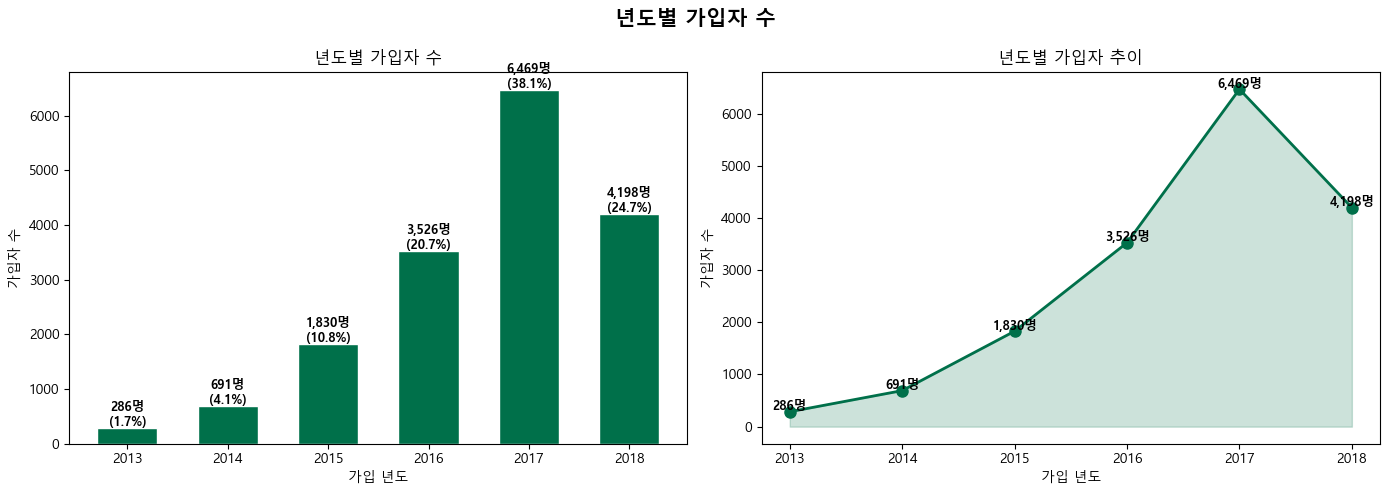

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("년도별 가입자 수", fontsize=15, fontweight="bold")

# 막대 차트
bars = axes[0].bar(year_counts.index.astype(str), year_counts.values, color="#00704A", edgecolor="white", width=0.6)
axes[0].set_title("년도별 가입자 수")
axes[0].set_xlabel("가입 년도")
axes[0].set_ylabel("가입자 수")
for bar, cnt, ratio in zip(bars, year_counts.values, year_ratio.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{cnt:,}명\n({ratio:.1f}%)",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

# 추세선 (꺾은선)
axes[1].plot(year_counts.index.astype(str), year_counts.values, marker="o", color="#00704A", linewidth=2, markersize=8)
axes[1].fill_between(year_counts.index.astype(str), year_counts.values, alpha=0.2, color="#00704A")
axes[1].set_title("년도별 가입자 추이")
axes[1].set_xlabel("가입 년도")
axes[1].set_ylabel("가입자 수")
for x, cnt in zip(year_counts.index.astype(str), year_counts.values):
    axes[1].text(x, cnt + 30, f"{cnt:,}명", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

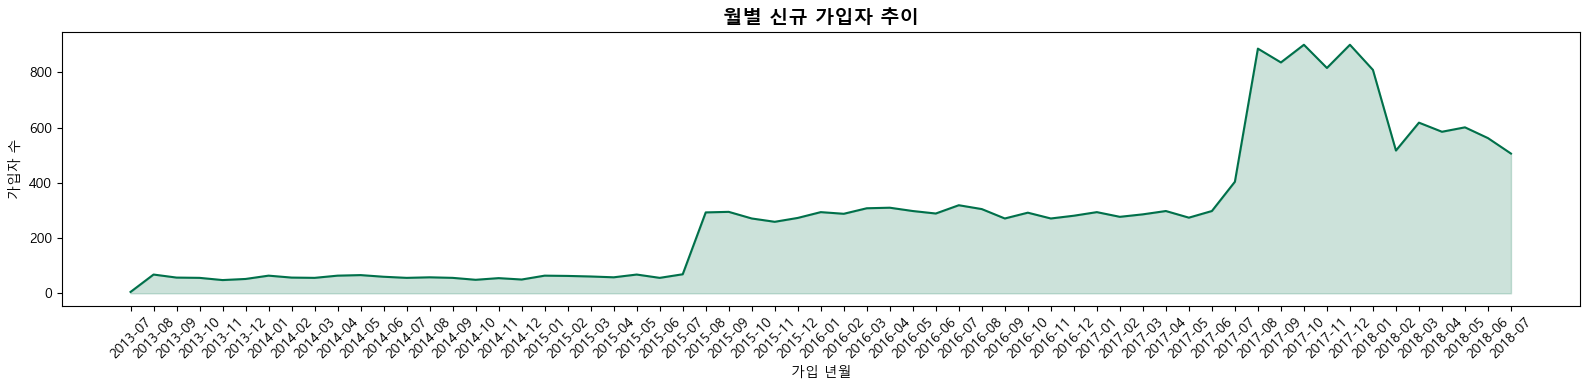

In [7]:
# 월별 가입자 추이 (년도-월)
df_unique["year_month"] = df_unique["became_member_on"].dt.to_period("M")
ym_counts = df_unique["year_month"].value_counts().sort_index()

plt.figure(figsize=(16, 4))
plt.plot(ym_counts.index.astype(str), ym_counts.values, color="#00704A", linewidth=1.5)
plt.fill_between(ym_counts.index.astype(str), ym_counts.values, alpha=0.2, color="#00704A")
plt.title("월별 신규 가입자 추이", fontsize=14, fontweight="bold")
plt.xlabel("가입 년월")
plt.ylabel("가입자 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- 2013~2017 지속 증가, 2018 감소
- 2017년이 최고점
- 2018 감소는 데이터 수집 기간이 짧아서일 가능성

추가 확인 필요: 2018년 데이터가 몇 월까지인지

# | **고객 분포**
- 성별/연령/소득

In [8]:
# 중복 제거 후 gender_counts 계산
df_unique = df.drop_duplicates(subset=["customer_id"])

gender_counts = df_unique["gender"].value_counts()
gender_ratio = df_unique["gender"].value_counts(normalize=True) * 100

print(gender_counts)
print()
print(gender_ratio.round(1))

gender
M          8484
F          6129
Unknown    2175
O           212
Name: count, dtype: int64

gender
M         49.90
F         36.10
Unknown   12.80
O          1.20
Name: proportion, dtype: float64


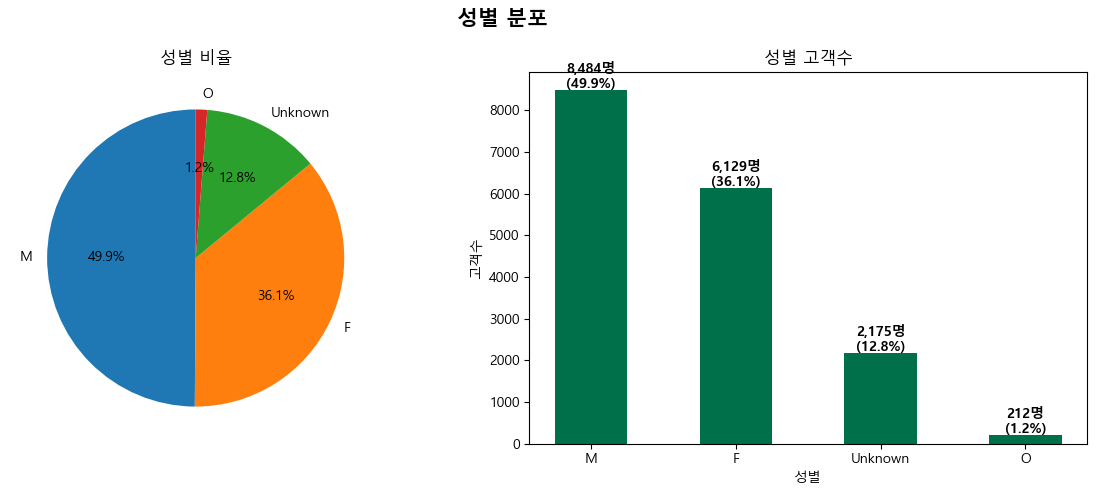

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("성별 분포", fontsize=15, fontweight="bold")

# 0
axes[0].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("성별 비율")

# 1
bars = axes[1].bar(gender_counts.index, gender_counts.values, color="#00704A", width=0.5)
axes[1].set_title("성별 고객수")
axes[1].set_xlabel("성별")
axes[1].set_ylabel("고객수")

# 막대 위에 글씨
for bar, (cnt, ratio) in zip(bars, zip(gender_counts.values, gender_ratio.values)):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{cnt:,}명\n({ratio:.1f}%)",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

### 성별 분포 해석
- 남성이 전체의 50%이상으로 과반수
- Unknown이 11% 성별 + Others는 1.3%, 논의 후 제외 가능
- 여성보다 남성 고객 수가 14% 더 많기 때문에 오퍼 완료도 많게 나올 수 있음 -> 분석 시 주의

In [10]:
# 연령 분포
print(df_unique["age"].describe())
print()
print(df_unique["age_group"].value_counts())

count   14825.00
mean       54.39
std        17.38
min        18.00
25%        42.00
50%        55.00
75%        66.00
max       101.00
Name: age, dtype: float64

age_group
60대 이상    5875
50대       3541
40대       2309
누락        2175
30대       1526
20대       1369
20대 미만     205
Name: count, dtype: int64


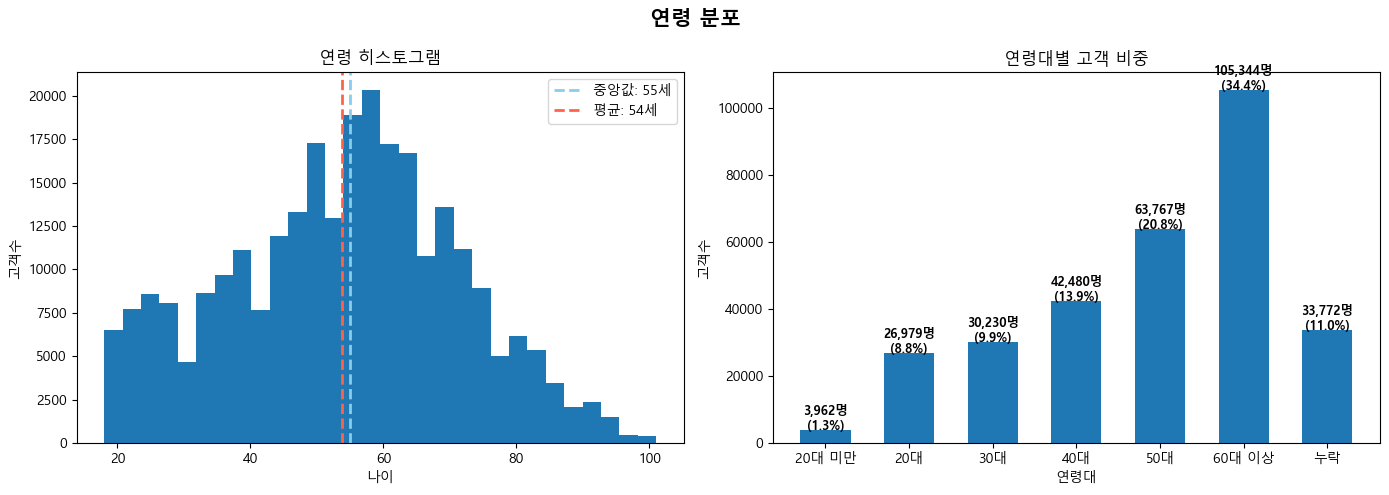

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("연령 분포", fontsize=15, fontweight="bold")

# 0 # 히스토그램
valid_df = df[df["is_profile_missing"] == 0]

axes[0].hist(valid_df["age"].dropna(), bins=30, linewidth=0.8)
axes[0].axvline(
    valid_df["age"].median(),
    color="skyblue",
    linestyle="--",
    linewidth=2,
    label=f"중앙값: {valid_df['age'].median():.0f}세",
)
axes[0].axvline(
    valid_df["age"].mean(), color="tomato", linestyle="--", linewidth=2, label=f"평균: {valid_df['age'].mean():.0f}세"
)
axes[0].set_title("연령 히스토그램")
axes[0].set_xlabel("나이")
axes[0].set_ylabel("고객수")
axes[0].legend()

# 1 # 막대 차트
age_order = ["20대 미만", "20대", "30대", "40대", "50대", "60대 이상", "누락"]
age_counts = df["age_group"].value_counts().reindex(age_order)
age_group_ratio = df["age_group"].value_counts(normalize=True).reindex(age_order) * 100

bars = axes[1].bar(age_counts.index, age_counts.values, width=0.6)
axes[1].set_title("연령대별 고객 비중")
axes[1].set_xlabel("연령대")
axes[1].set_ylabel("고객수")

for bar, cnt, ratio in zip(bars, age_counts.values, age_group_ratio.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{cnt:,}명\n({ratio:.1f}%)",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

### 연령 분포 해석
- 60대 이상 전체의 34.4%, 가장 큰 비중
- 40~60대가 전체의 69.1% -> 어떤 프로모션 유형이 가장 효과적이었는지 확인 필요
- 중앙값 55세, 평균 54세 / 50~60세 구간 편중
- 2-30대는 상대적으로 적은 비중

실제 오퍼 참여 고객이 중장년층이 더 많았다. 
- -> 중장년층이 참여한 오퍼 유형 간 차이가 보이는지 확인할 것
- -> ['web', 'email', 'mobile', 'social'] 어떤 채널이 참여율이 더 높은지 확인해볼 것

In [12]:
# 소득 분포
print(df_unique["income"].describe())
print()

income_order = ["5만 미만", "5-7.5만", "7.5-10만", "10만 이상", "누락"]
income_counts = df_unique["income_group"].value_counts().reindex(income_order)
income_ratio = df_unique["income_group"].value_counts(normalize=True).reindex(income_order) * 100

print(income_counts)

count    17000.00
mean     57037.00
std      29734.04
min          0.00
25%      40000.00
50%      59000.00
75%      76000.00
max     120000.00
Name: income, dtype: float64

income_group
5만 미만      3781
5-7.5만     6446
7.5-10만    3505
10만 이상     1093
누락         2175
Name: count, dtype: int64


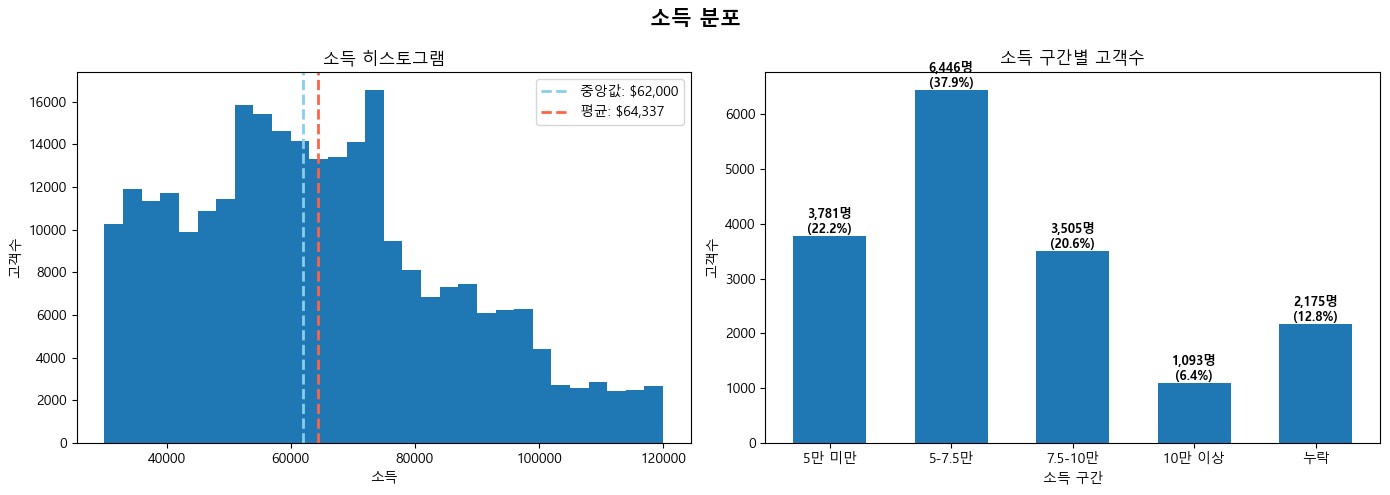

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("소득 분포", fontsize=15, fontweight="bold")

# 0 # 히스토그램
valid_df = df[df["is_profile_missing"] == 0]

axes[0].hist(valid_df["income"].dropna(), bins=30, linewidth=0.8)
axes[0].axvline(
    valid_df["income"].median(),
    color="skyblue",
    linestyle="--",
    linewidth=2,
    label=f"중앙값: ${valid_df['income'].median():,.0f}",
)
axes[0].axvline(
    valid_df["income"].mean(),
    color="tomato",
    linestyle="--",
    linewidth=2,
    label=f"평균: ${valid_df['income'].mean():,.0f}",
)
axes[0].set_title("소득 히스토그램")
axes[0].set_xlabel("소득")
axes[0].set_ylabel("고객수")
axes[0].legend()

# 1 # 막대 차트
bars = axes[1].bar(income_counts.index, income_counts.values, width=0.6)
axes[1].set_title("소득 구간별 고객수")
axes[1].set_xlabel("소득 구간")
axes[1].set_ylabel("고객수")

for bar, cnt, ratio in zip(bars, income_counts.values, income_ratio.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{cnt:,}명\n({ratio:.1f}%)",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

### 소득 분포 해석
- 5~7.5 구간 집중(39.9%), 고소득 가장 적음
- 중앙값 62,000달러, 평균 64,337달러로 비슷함

5-7.5만 구간이 40% / 5만 미만이 23.7% / 고소득층(10만 이상)은 5.9%

In [14]:
# is_aware
print(df.columns)
print()
print(df["event"].value_counts())

Index(['customer_id', 'event', 'time', 'amount', 'offer_id', 'actual_reward',
       'day', 'reward', 'difficulty', 'duration', 'offer_type', 'ch_web',
       'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio',
       'offer_strength', 'gender', 'age', 'became_member_on', 'income',
       'is_profile_missing', 'age_group', 'age_gender', 'income_group',
       'time_comp', 'time_view', 'is_aware'],
      dtype='str')

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64


### 윤서님 is_aware 코드 활용
- "오퍼를 보지도 않은 사람의 구매를 마케팅 효과로 착각하지 않기 위해서"

In [15]:
aware_counts = df["is_aware"].value_counts()
aware_ratio = df["is_aware"].value_counts(normalize=True) * 100

print("is_aware 분포:")
print(f"True  (오퍼 인지 후 구매) : {aware_counts[True]:,}건  ({aware_ratio[True]:.1f}%)")
print(f"False (오퍼 미인지 구매)  : {aware_counts[False]:,}건  ({aware_ratio[False]:.1f}%)")

is_aware 분포:
True  (오퍼 인지 후 구매) : 23,416건  (61.0%)
False (오퍼 미인지 구매)  : 14,991건  (39.0%)


In [16]:
df[df["offer_type"] == "informational"]["event"].value_counts()

event
offer received    15235
offer viewed      10831
Name: count, dtype: int64

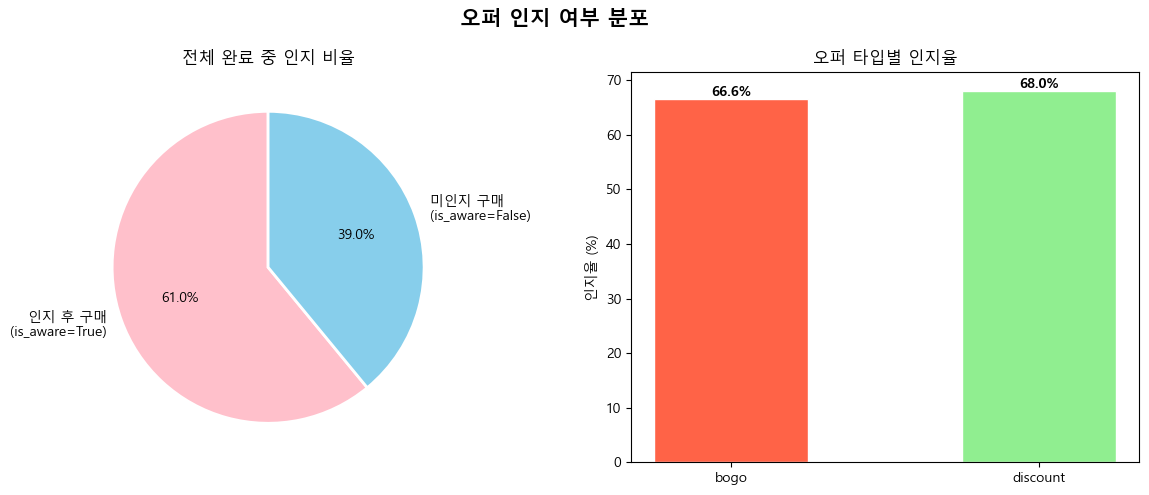

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("오퍼 인지 여부 분포", fontsize=15, fontweight="bold")

# 전체 비율
labels = ["인지 후 구매\n(is_aware=True)", "미인지 구매\n(is_aware=False)"]
vals = [aware_counts[True], aware_counts[False]]
axes[0].pie(
    vals,
    labels=labels,
    autopct="%1.1f%%",
    colors=["pink", "skyblue"],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    startangle=90,
)
axes[0].set_title("전체 완료 중 인지 비율")

# 오퍼 타입별 인지율
comp_df = df[df["event"] == "offer completed"].copy()
comp_df = comp_df[~comp_df["offer_type"].str.contains("informational", na=False)]
offer_aware = comp_df.groupby("offer_type")["is_aware"].mean() * 100

bars = axes[1].bar(offer_aware.index, offer_aware.values, color=["tomato", "lightgreen"], edgecolor="white", width=0.5)
axes[1].set_title("오퍼 타입별 인지율")
axes[1].set_ylabel("인지율 (%)")
for bar, val in zip(bars, offer_aware.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{val:.1f}%", ha="center", fontweight="bold"
    )

plt.tight_layout()
plt.show()

- 전체 완료의 61% 만이 오퍼 인지 후 구매
- 39%는 마케팅 효과 없이 자연 구매

BOGO(66.6%) vs Discount(68.0%) 인지율 비슷 -> 전환율 수치 의심

In [18]:
# 소득 구간별 거래
trans = df[df["event"] == "transaction"].copy()

income_order = ["5만 미만", "5-7.5만", "7.5-10만", "10만 이상", "누락"]

income_stats = (
    trans.groupby("income_group")["amount"]
    .agg(고객수="count", 평균구매액="mean", 중앙값="median", 총구매액="sum")
    .reindex(income_order)
)

print(income_stats)

                고객수  평균구매액   중앙값      총구매액
income_group                              
5만 미만         37949   6.68  4.45 253632.12
5-7.5만        56976  12.32 10.45 701677.29
7.5-10만       22380  25.65 22.14 574150.66
10만 이상         6652  30.89 26.55 205482.33
누락            14996   2.70  1.71  40509.57


### 소득 구간별 평균 구매 금액 / 총 구매액 해석
- 소득 크면 -> 1회 구매금액도 크다
- 5-7.5만
    - 고객수 가장 많음 / 총매출 가장큼
    - 평균 $12 / 구매 빈도나 객단가를 올리는 업셀링 전략 필요

- 10만 이상 고객은 5.9%에 불과하지만 1인당 $30.9로 압도적
    - 이 구간 고객을 유지·락인하는 것이 ROI가 가장 높음
    - 프리미엄 오퍼나 VIP 혜택이 효과적일 가능성

- 5만 미만
    - 고객 수(37,949명)에 비해 총매출($253,632)이 낮음
    - 평균 $6.7로 소액 구매에 그침 → BOGO처럼 체감 혜택 큰 오퍼로 구매 유도 필요

- 누락($2.7)
    - 고객정보 미입력 고객은 구매금액도 현저히 낮음
    - 앱 가입/프로파일 입력 유도 캠페인으로 데이터 확보 + 구매 활성화 동시 노릴 수 있음

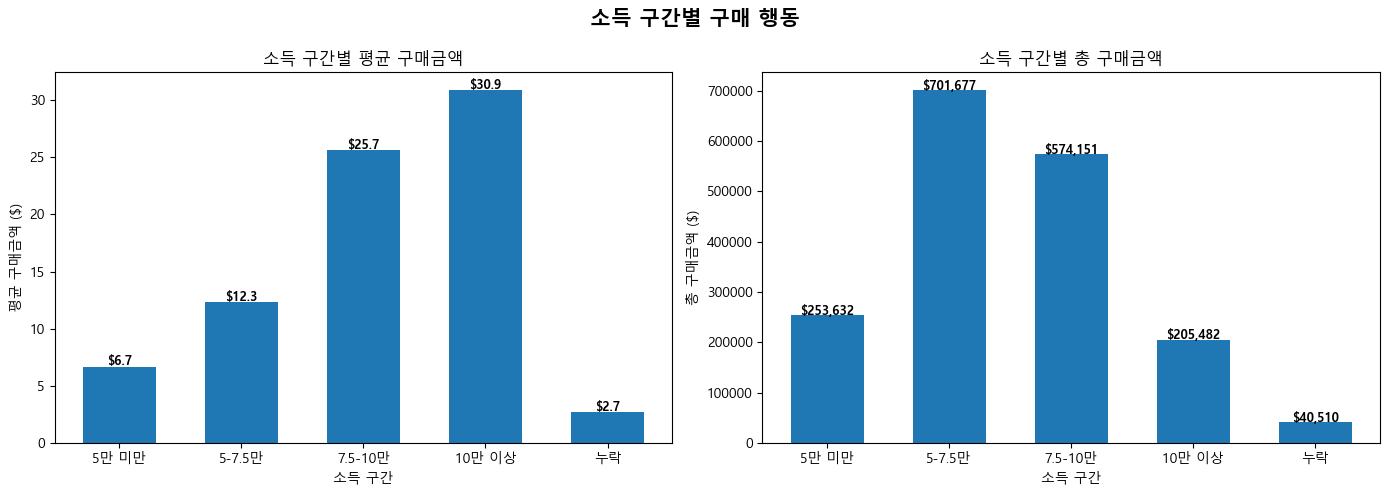

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("소득 구간별 구매 행동", fontsize=15, fontweight="bold")

# 평균 구매금액
bars1 = axes[0].bar(income_stats.index, income_stats["평균구매액"], width=0.6)
axes[0].set_title("소득 구간별 평균 구매금액")
axes[0].set_xlabel("소득 구간")
axes[0].set_ylabel("평균 구매금액 ($)")
# 글씨
for bar, val in zip(bars1, income_stats["평균구매액"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"${val:.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )


# 총 구매금액
bars2 = axes[1].bar(income_stats.index, income_stats["총구매액"], width=0.6)
axes[1].set_title("소득 구간별 총 구매금액")
axes[1].set_xlabel("소득 구간")
axes[1].set_ylabel("총 구매금액 ($)")
# 글씨
for bar, val in zip(bars2, income_stats["총구매액"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"${val:,.0f}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

In [20]:
# 활성 유저 비율
# 활성 유저 정의: transaction 1번 이상이거나 offer completed 1번 이상
active_customers = set(df[df["event"] == "transaction"]["customer_id"].unique()) | set(
    df[df["event"] == "offer completed"]["customer_id"].unique()
)

total_customers = df["customer_id"].nunique()
active_count = len(active_customers)
inactive_count = total_customers - active_count

active_ratio = active_count / total_customers * 100
inactive_ratio = inactive_count / total_customers * 100

print(f"전체 고객 수    : {total_customers:,}명")
print(f"활성 멤버       : {active_count:,}명 ({active_ratio:.1f}%)")
print(f"비활성 멤버     : {inactive_count:,}명 ({inactive_ratio:.1f}%)")

전체 고객 수    : 17,000명
활성 멤버       : 16,578명 (97.5%)
비활성 멤버     : 422명 (2.5%)


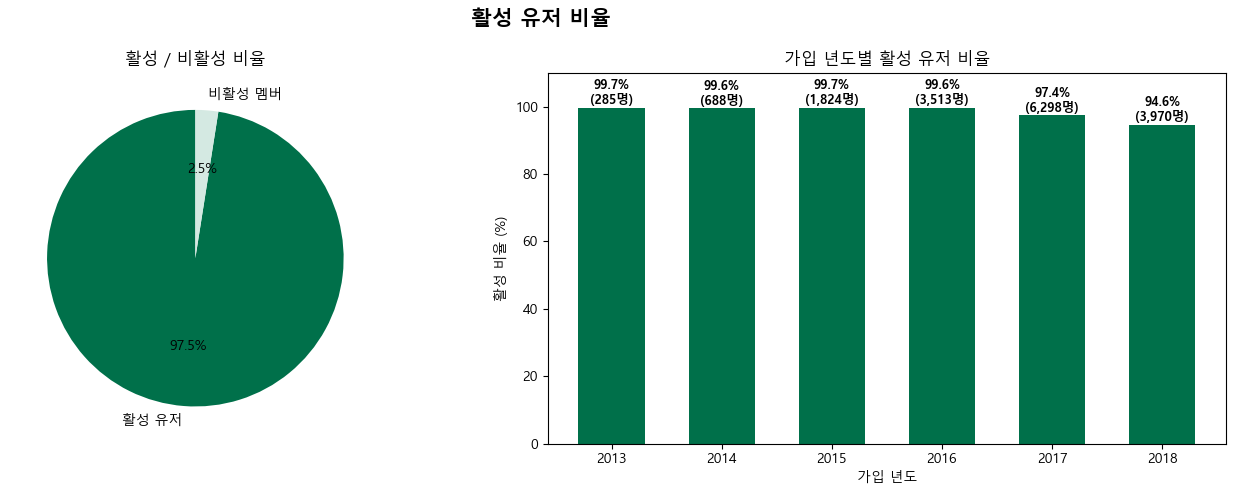

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("활성 유저 비율", fontsize=15, fontweight="bold")

labels = ["활성 유저", "비활성 멤버"]
counts = [active_count, inactive_count]
colors = ["#00704A", "#D4E9E2"]

# 파이 차트
axes[0].pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
)

axes[0].set_title("활성 / 비활성 비율")

# 년도별 활성 멤버 비율
df_unique = df.drop_duplicates("customer_id").copy()
df_unique["member_year"] = df_unique["became_member_on"].dt.year
df_unique["is_active"] = df_unique["customer_id"].isin(active_customers)

year_active = (
    df_unique.groupby("member_year").agg(전체=("customer_id", "count"), 활성=("is_active", "sum")).reset_index()
)
year_active["활성비율"] = year_active["활성"] / year_active["전체"] * 100

bars = axes[1].bar(year_active["member_year"].astype(str), year_active["활성비율"], color="#00704A", width=0.6)
axes[1].set_title("가입 년도별 활성 유저 비율")
axes[1].set_xlabel("가입 년도")
axes[1].set_ylabel("활성 비율 (%)")
axes[1].set_ylim(0, 110)

for bar, (_, row) in zip(bars, year_active.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{row['활성비율']:.1f}%\n({int(row['활성']):,}명)",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

In [22]:
# 거래 이벤트 건수
df[df["event"] == "transaction"]

,customer_id,event,time,amount,offer_id,actual_reward,day,reward,difficulty,duration,...,age,became_member_on,income,is_profile_missing,age_group,age_gender,income_group,time_comp,time_view,is_aware
12654,02c083884c7d45b39cc68e1314fec56c,transaction,0,0.83,NaN,NaN,0,NaN,NaN,NaN,...,20.00,2016-07-11,30000.00,0,20대,20대 여성,5만 미만,NaN,NaN,NaN
12657,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,transaction,0,34.56,NaN,NaN,0,NaN,NaN,NaN,...,42.00,2016-01-17,96000.00,0,40대,40대 남성,7.5-10만,NaN,NaN,NaN
12659,54890f68699049c2a04d415abc25e717,transaction,0,13.23,NaN,NaN,0,NaN,NaN,NaN,...,36.00,2017-12-28,56000.00,0,30대,30대 남성,5-7.5만,NaN,NaN,NaN
12670,b2f1cd155b864803ad8334cdf13c4bd2,transaction,0,19.51,NaN,NaN,0,NaN,NaN,NaN,...,55.00,2017-10-16,94000.00,0,50대,50대 여성,7.5-10만,NaN,NaN,NaN
12671,fe97aa22dd3e48c8b143116a8403dd52,transaction,0,18.97,NaN,NaN,0,NaN,NaN,NaN,...,39.00,2017-12-17,67000.00,0,30대,30대 여성,5-7.5만,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,714,1.59,NaN,NaN,29,NaN,NaN,NaN,...,66.00,2018-01-01,47000.00,0,60대 이상,60대 남성,5만 미만,NaN,NaN,NaN
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,9.53,NaN,NaN,29,NaN,NaN,NaN,...,52.00,2018-04-08,62000.00,0,50대,50대 남성,5-7.5만,NaN,NaN,NaN
306531,a00058cf10334a308c68e7631c529907,transaction,714,3.61,NaN,NaN,29,NaN,NaN,NaN,...,63.00,2013-09-22,52000.00,0,60대 이상,60대 여성,5-7.5만,NaN,NaN,NaN
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,714,3.53,NaN,NaN,29,NaN,NaN,NaN,...,57.00,2016-07-09,40000.00,0,50대,50대 남성,5만 미만,NaN,NaN,NaN


In [23]:
# transaction 이벤트만 추출
tx = df[df["event"] == "transaction"][["customer_id", "day"]].sort_values(["customer_id", "day"])

# 고객별 다음 구매일 계산
tx["next_purchase_day"] = tx.groupby("customer_id")["day"].shift(-1)
tx["days_until_next"] = tx["next_purchase_day"] - tx["day"]

# 고객별 90일 내 재구매 여부
repurchase = (
    tx.groupby("customer_id")
    .agg(
        총구매횟수=("day", "count"),
        최소재구매간격=("days_until_next", "min"),
    )
    .reset_index()
)

repurchase["90일내_재구매"] = repurchase["최소재구매간격"] <= 90

total = len(repurchase)
repurchase_count = repurchase["90일내_재구매"].sum()
no_repurchase_count = total - repurchase_count

print(f"구매 이력 있는 전체 고객  : {total:,}명")
print(f"90일 내 재구매 고객       : {repurchase_count:,}명 ({repurchase_count/total*100:.1f}%)")
print(f"90일 내 재구매 없는 고객  : {no_repurchase_count:,}명 ({no_repurchase_count/total*100:.1f}%)")

구매 이력 있는 전체 고객  : 16,578명
90일 내 재구매 고객       : 16,177명 (97.6%)
90일 내 재구매 없는 고객  : 401명 (2.4%)


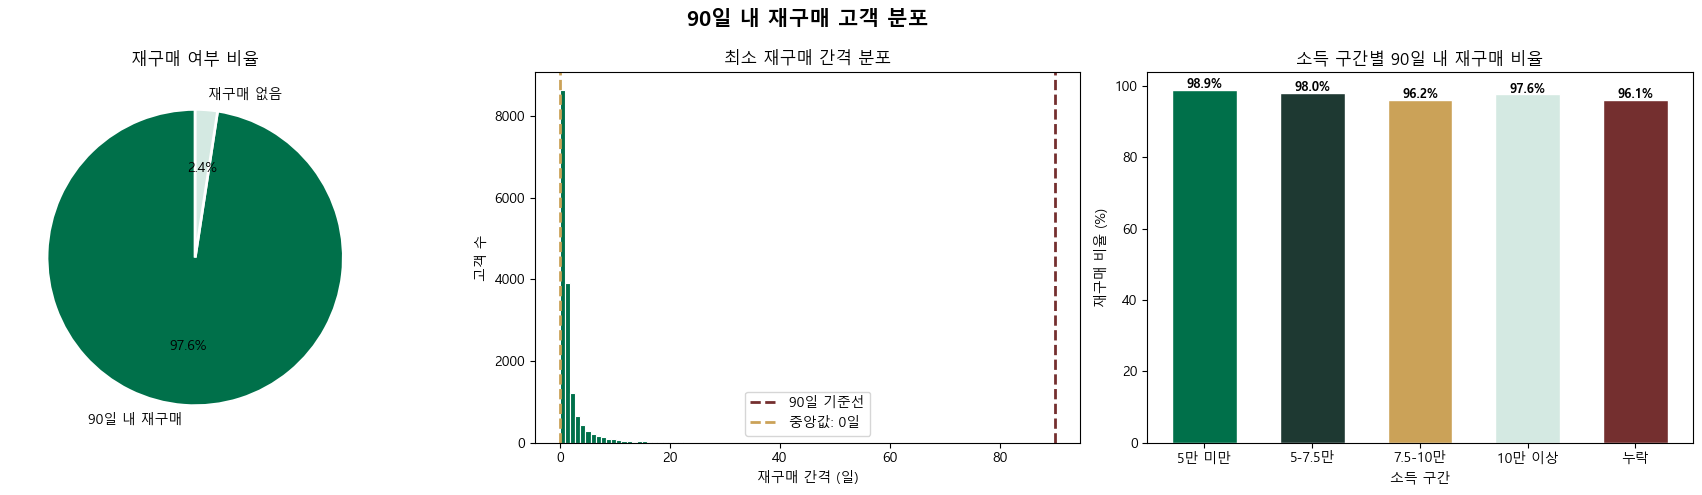

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("90일 내 재구매 고객 분포", fontsize=15, fontweight="bold")

# 파이 차트
labels = ["90일 내 재구매", "재구매 없음"]
counts = [repurchase_count, no_repurchase_count]
axes[0].pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    colors=["#00704A", "#D4E9E2"],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    startangle=90,
)
axes[0].set_title("재구매 여부 비율")

# 재구매 간격 분포 히스토그램
valid_interval = repurchase["최소재구매간격"].dropna()
axes[1].hist(valid_interval, bins=30, color="#00704A", edgecolor="white", linewidth=0.8)
axes[1].axvline(90, color="#742F2F", linestyle="--", linewidth=2, label="90일 기준선")
axes[1].axvline(
    valid_interval.median(),
    color="#CBA258",
    linestyle="--",
    linewidth=2,
    label=f"중앙값: {valid_interval.median():.0f}일",
)
axes[1].set_title("최소 재구매 간격 분포")
axes[1].set_xlabel("재구매 간격 (일)")
axes[1].set_ylabel("고객 수")
axes[1].legend()

# 소득 구간별 재구매 비율
repurchase_prof = repurchase.merge(
    df[["customer_id", "income_group"]].drop_duplicates("customer_id"), on="customer_id", how="left"
)
income_order = ["5만 미만", "5-7.5만", "7.5-10만", "10만 이상", "누락"]
income_repurchase = (
    repurchase_prof.groupby("income_group")
    .agg(전체=("customer_id", "count"), 재구매=("90일내_재구매", "sum"))
    .reindex(income_order)
)
income_repurchase["비율"] = income_repurchase["재구매"] / income_repurchase["전체"] * 100

bars = axes[2].bar(
    income_repurchase.index,
    income_repurchase["비율"],
    color=["#00704A", "#1E3932", "#CBA258", "#D4E9E2", "#742F2F"],
    edgecolor="white",
    width=0.6,
)
axes[2].set_title("소득 구간별 90일 내 재구매 비율")
axes[2].set_xlabel("소득 구간")
axes[2].set_ylabel("재구매 비율 (%)")
for bar, val in zip(bars, income_repurchase["비율"]):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

- 구매 고객 97.6%가 90일 내 재구매
- 평균 7.6회, 중앙값 7회
- 충성도 높은 고객층이 대부분
- 재구매 간격이 짧은 고객에게 오퍼 집중 필요

In [25]:
# transaction 이벤트만 추출
tx = df[df["event"] == "transaction"][["customer_id", "day"]].sort_values(["customer_id", "day"])

# 고객별 다음 구매일 계산
tx["next_purchase_day"] = tx.groupby("customer_id")["day"].shift(-1)
tx["days_until_next"] = tx["next_purchase_day"] - tx["day"]

# 90일 내 재구매 건수만 필터링
tx_90 = tx[tx["days_until_next"] <= 90]

# 고객별 90일 내 재구매 빈도
repurchase_freq = tx_90.groupby("customer_id").size().reset_index(name="재구매횟수")

print(f"90일 내 재구매 고객 수 : {len(repurchase_freq):,}명")
print(f"평균 재구매 횟수       : {repurchase_freq['재구매횟수'].mean():.1f}회")
print(f"중앙값 재구매 횟수     : {repurchase_freq['재구매횟수'].median():.0f}회")
print(f"최대 재구매 횟수       : {repurchase_freq['재구매횟수'].max():.0f}회")

90일 내 재구매 고객 수 : 16,177명
평균 재구매 횟수       : 7.6회
중앙값 재구매 횟수     : 7회
최대 재구매 횟수       : 35회


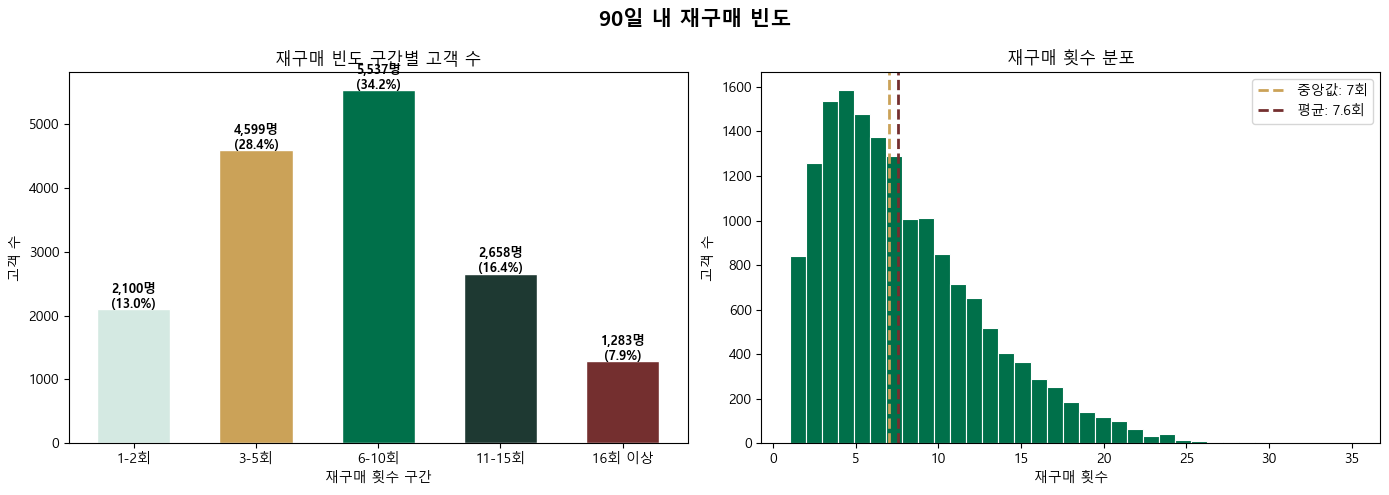

In [26]:
# 빈도 구간
bins = [0, 2, 5, 10, 15, 35]
labels = ["1-2회", "3-5회", "6-10회", "11-15회", "16회 이상"]
repurchase_freq["빈도구간"] = pd.cut(repurchase_freq["재구매횟수"], bins=bins, labels=labels)

freq_counts = repurchase_freq["빈도구간"].value_counts().reindex(labels)
freq_ratio = repurchase_freq["빈도구간"].value_counts(normalize=True).reindex(labels) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("90일 내 재구매 빈도", fontsize=15, fontweight="bold")

# 빈도 구간별 막대 차트
bars = axes[0].bar(
    freq_counts.index,
    freq_counts.values,
    color=["#D4E9E2", "#CBA258", "#00704A", "#1E3932", "#742F2F"],
    edgecolor="white",
    width=0.6,
)
axes[0].set_title("재구매 빈도 구간별 고객 수")
axes[0].set_xlabel("재구매 횟수 구간")
axes[0].set_ylabel("고객 수")
for bar, cnt, ratio in zip(bars, freq_counts.values, freq_ratio.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{cnt:,}명\n({ratio:.1f}%)",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

# 재구매 횟수 히스토그램
axes[1].hist(repurchase_freq["재구매횟수"], bins=35, color="#00704A", edgecolor="white", linewidth=0.8)
axes[1].axvline(
    repurchase_freq["재구매횟수"].median(),
    color="#CBA258",
    linestyle="--",
    linewidth=2,
    label=f"중앙값: {repurchase_freq['재구매횟수'].median():.0f}회",
)
axes[1].axvline(
    repurchase_freq["재구매횟수"].mean(),
    color="#742F2F",
    linestyle="--",
    linewidth=2,
    label=f"평균: {repurchase_freq['재구매횟수'].mean():.1f}회",
)
axes[1].set_title("재구매 횟수 분포")
axes[1].set_xlabel("재구매 횟수")
axes[1].set_ylabel("고객 수")
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
# 채널별 고객 특성 분석
# offer received 기준으로 각 채널을 받은 고객의 인구통계 비교

received = df[df["event"] == "offer received"].copy()

channels = ["ch_email", "ch_web", "ch_mobile", "ch_social"]
ch_names = ["Email", "Web", "Mobile", "Social"]
age_order = ["20대 미만", "20대", "30대", "40대", "50대", "60대 이상", "누락"]
income_order = ["5만 미만", "5-7.5만", "7.5-10만", "10만 이상", "누락"]

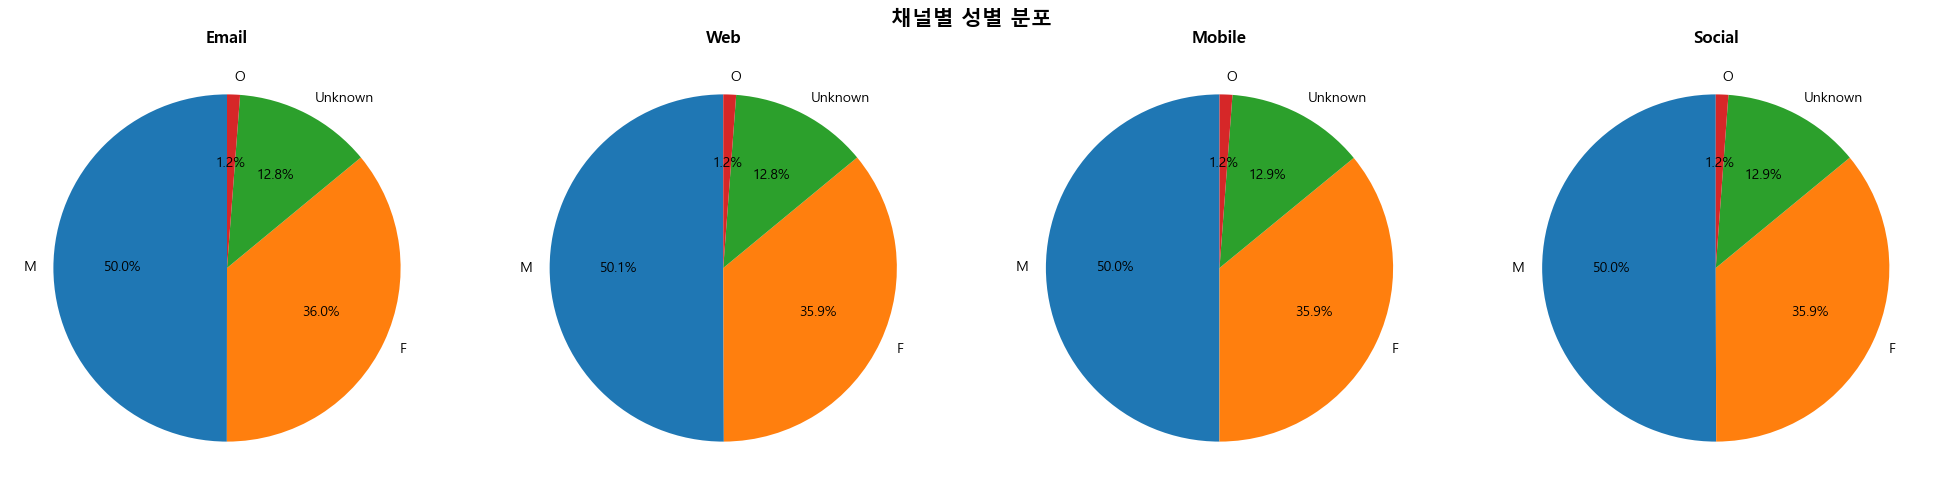

In [28]:
# 성별 × 채널
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("채널별 성별 분포", fontsize=15, fontweight="bold")

for ax, col, name in zip(axes, channels, ch_names):
    sub = received[received[col] == 1]
    gender_r = sub["gender"].value_counts(normalize=True) * 100
    ax.pie(
        gender_r,
        labels=gender_r.index,
        autopct="%1.1f%%",
        startangle=90,
    )
    ax.set_title(f"{name}", fontweight="bold")

plt.tight_layout()
plt.show()

- 채널 간 평균 연령/소득/성별 차이 거의 없음
- 동일 오퍼가 여러 채널에 동시 발송되기 때문

채널 자체보다 채널 수가 더 중요한 변수

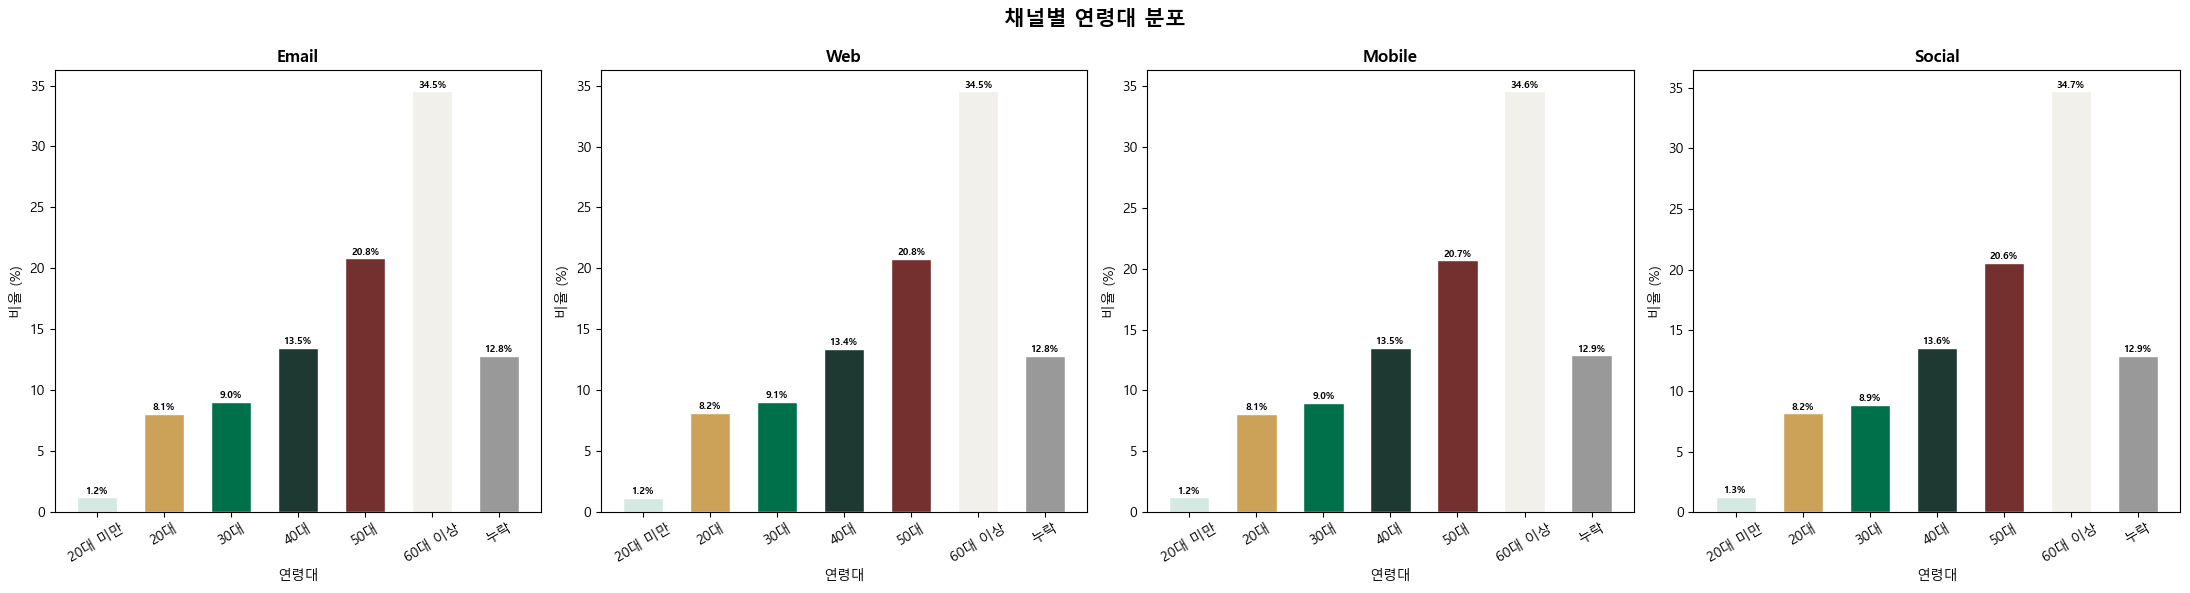

In [29]:
# 연령대 × 채널
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("채널별 연령대 분포", fontsize=15, fontweight="bold")

for ax, col, name in zip(axes, channels, ch_names):
    sub = received[received[col] == 1]
    age_r = sub["age_group"].value_counts(normalize=True).reindex(age_order) * 100
    colors = ["#D4E9E2", "#CBA258", "#00704A", "#1E3932", "#742F2F", "#F2F0EB", "#999999"]
    bars = ax.bar(age_r.index, age_r.values, color=colors, edgecolor="white", width=0.6)
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("연령대")
    ax.set_ylabel("비율 (%)")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, age_r.values):
        if val > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val:.1f}%",
                ha="center",
                fontsize=7,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

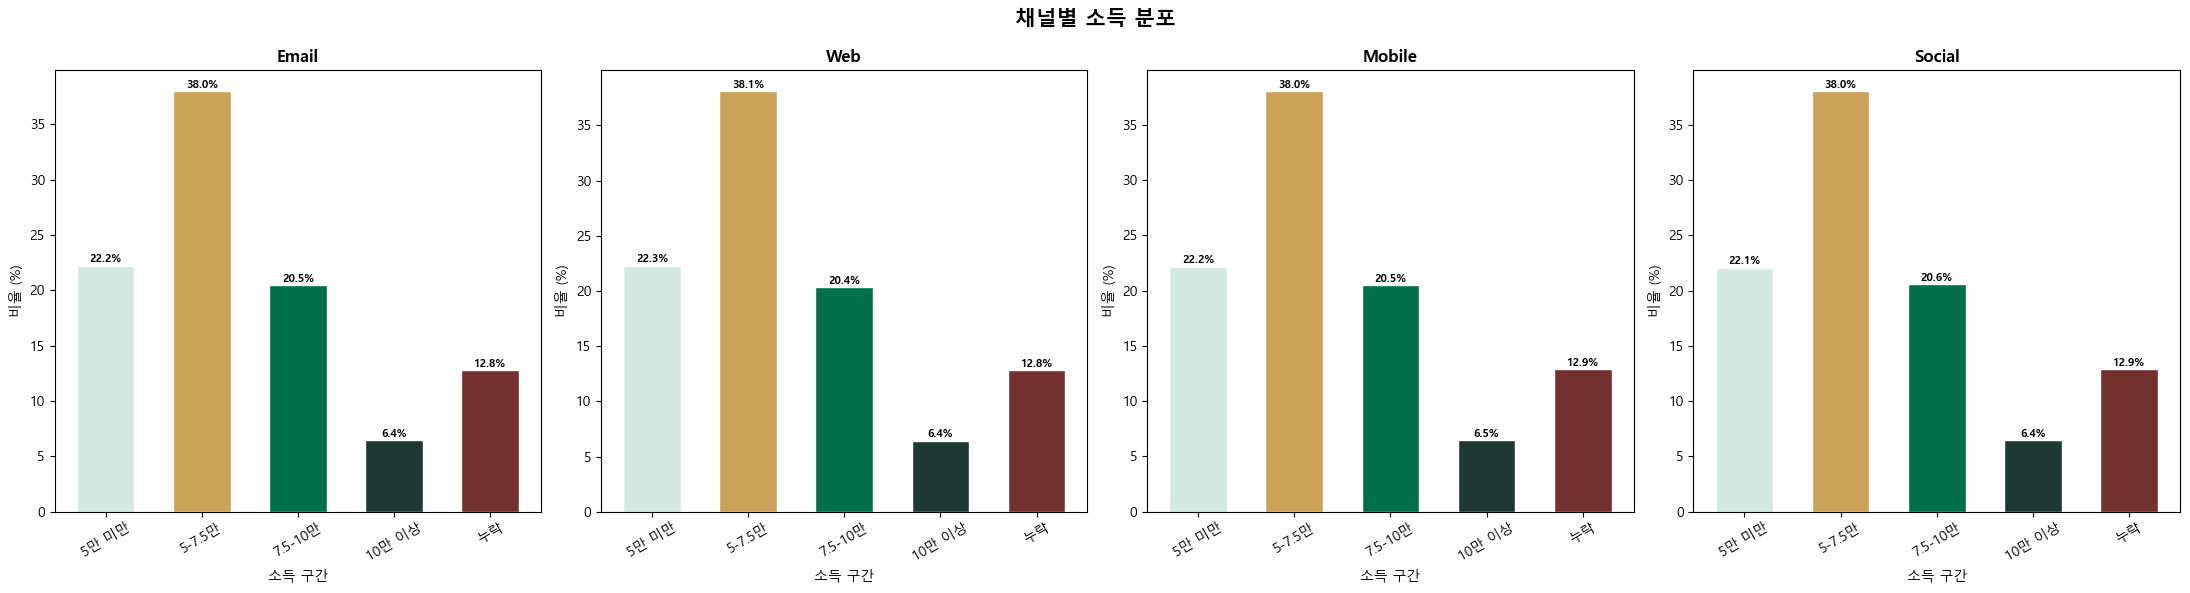

In [30]:
# 소득 × 채널
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("채널별 소득 분포", fontsize=15, fontweight="bold")

for ax, col, name in zip(axes, channels, ch_names):
    sub = received[received[col] == 1]
    inc_r = sub["income_group"].value_counts(normalize=True).reindex(income_order) * 100
    colors = ["#D4E9E2", "#CBA258", "#00704A", "#1E3932", "#742F2F"]
    bars = ax.bar(inc_r.index, inc_r.values, color=colors, edgecolor="white", width=0.6)
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("소득 구간")
    ax.set_ylabel("비율 (%)")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, inc_r.values):
        if val > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val:.1f}%",
                ha="center",
                fontsize=8,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

In [31]:
# 채널별 평균 연령 / 평균 소득 비교
summary = []
for col, name in zip(channels, ch_names):
    sub = received[received[col] == 1]
    summary.append(
        {
            "채널": name,
            "오퍼 수신 수": len(sub),
            "평균 연령": sub["age"].mean(),
            "평균 소득": sub["income"].mean(),
            "여성 비율": (sub["gender"] == "F").sum() / len(sub) * 100,
            "남성 비율": (sub["gender"] == "M").sum() / len(sub) * 100,
        }
    )

summary_df = pd.DataFrame(summary).set_index("채널")
print(summary_df.round(1).to_string())

        오퍼 수신 수  평균 연령    평균 소득  여성 비율  남성 비율
채널                                           
Email     76277  54.40 56993.30  36.00  50.00
Web       61001  54.40 56942.70  35.90  50.10
Mobile    68609  54.40 56973.30  35.90  50.00
Social    45683  54.40 57029.60  35.90  50.00


In [32]:
# 유효 고객만 (프로파일 누락 제외)
valid = df[df["is_profile_missing"] == 0][["age", "income"]].dropna()

# 상관계수
corr = valid["age"].corr(valid["income"])
print(f"연령-소득 상관계수 (Pearson): {corr:.4f}")

연령-소득 상관계수 (Pearson): 0.2987


C:\Users\wuevu\AppData\Local\Temp\ipykernel_21864\3289007158.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_group, labels=age_order, patch_artist=True)


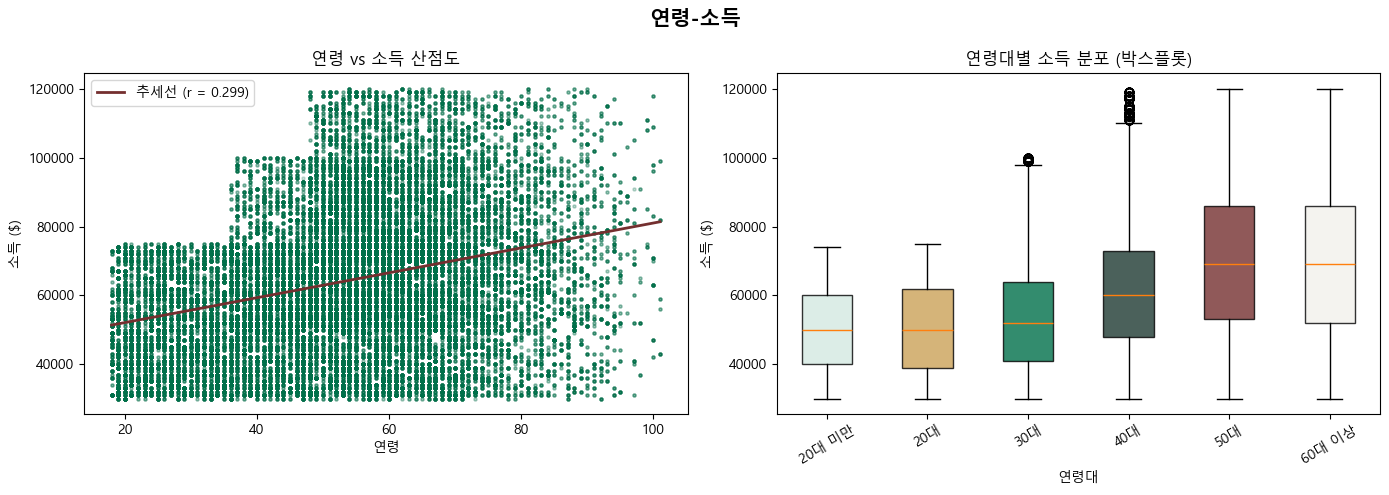

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("연령-소득", fontsize=15, fontweight="bold")

# 산점도
axes[0].scatter(valid["age"], valid["income"], alpha=0.05, color="#00704A", s=5)

# 추세선
z = np.polyfit(valid["age"], valid["income"], 1)
p = np.poly1d(z)
x_line = np.linspace(valid["age"].min(), valid["age"].max(), 100)
axes[0].plot(x_line, p(x_line), color="#742F2F", linewidth=2, label=f"추세선 (r = {corr:.3f})")
axes[0].set_title("연령 vs 소득 산점도")
axes[0].set_xlabel("연령")
axes[0].set_ylabel("소득 ($)")
axes[0].legend()

# 연령대별 평균 소득 박스플롯
age_order = ["20대 미만", "20대", "30대", "40대", "50대", "60대 이상"]
valid_group = df[(df["is_profile_missing"] == 0) & (df["age_group"] != "누락")][["age_group", "income"]].dropna()

data_by_group = [valid_group[valid_group["age_group"] == g]["income"].values for g in age_order]
bp = axes[1].boxplot(data_by_group, labels=age_order, patch_artist=True)

colors = ["#D4E9E2", "#CBA258", "#00704A", "#1E3932", "#742F2F", "#F2F0EB"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[1].set_title("연령대별 소득 분포 (박스플롯)")
axes[1].set_xlabel("연령대")
axes[1].set_ylabel("소득 ($)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [34]:
# 연령대별 평균소득 /중앙값소득
age_income = (
    valid_group.groupby("age_group")["income"]
    .agg(평균소득="mean", 중앙값소득="median", 표준편차="std")
    .reindex(age_order)
)

print(age_income.round(0))

              평균소득    중앙값소득     표준편차
age_group                           
20대 미만    50498.00 50000.00 12542.00
20대       51167.00 50000.00 13055.00
30대       53621.00 52000.00 15100.00
40대       61113.00 60000.00 18231.00
50대       69813.00 69000.00 21890.00
60대 이상    69291.00 69000.00 22316.00


In [35]:
# 연령대 - 소득 구간 교차표
pd.crosstab(df["age_group"], df["income_group"], normalize="index") * 100

income_group,10만 이상,5-7.5만,5만 미만,7.5-10만,누락
age_group,,,,,
20대,0.00,51.43,47.76,0.82,0.00
20대 미만,0.00,51.41,48.59,0.00,0.00
30대,0.16,51.16,42.28,6.40,0.00
40대,1.99,51.50,27.40,19.11,0.00
50대,9.83,41.13,19.00,30.04,0.00
60대 이상,10.23,40.72,20.14,28.90,0.00
누락,0.00,0.00,0.00,0.00,100.00


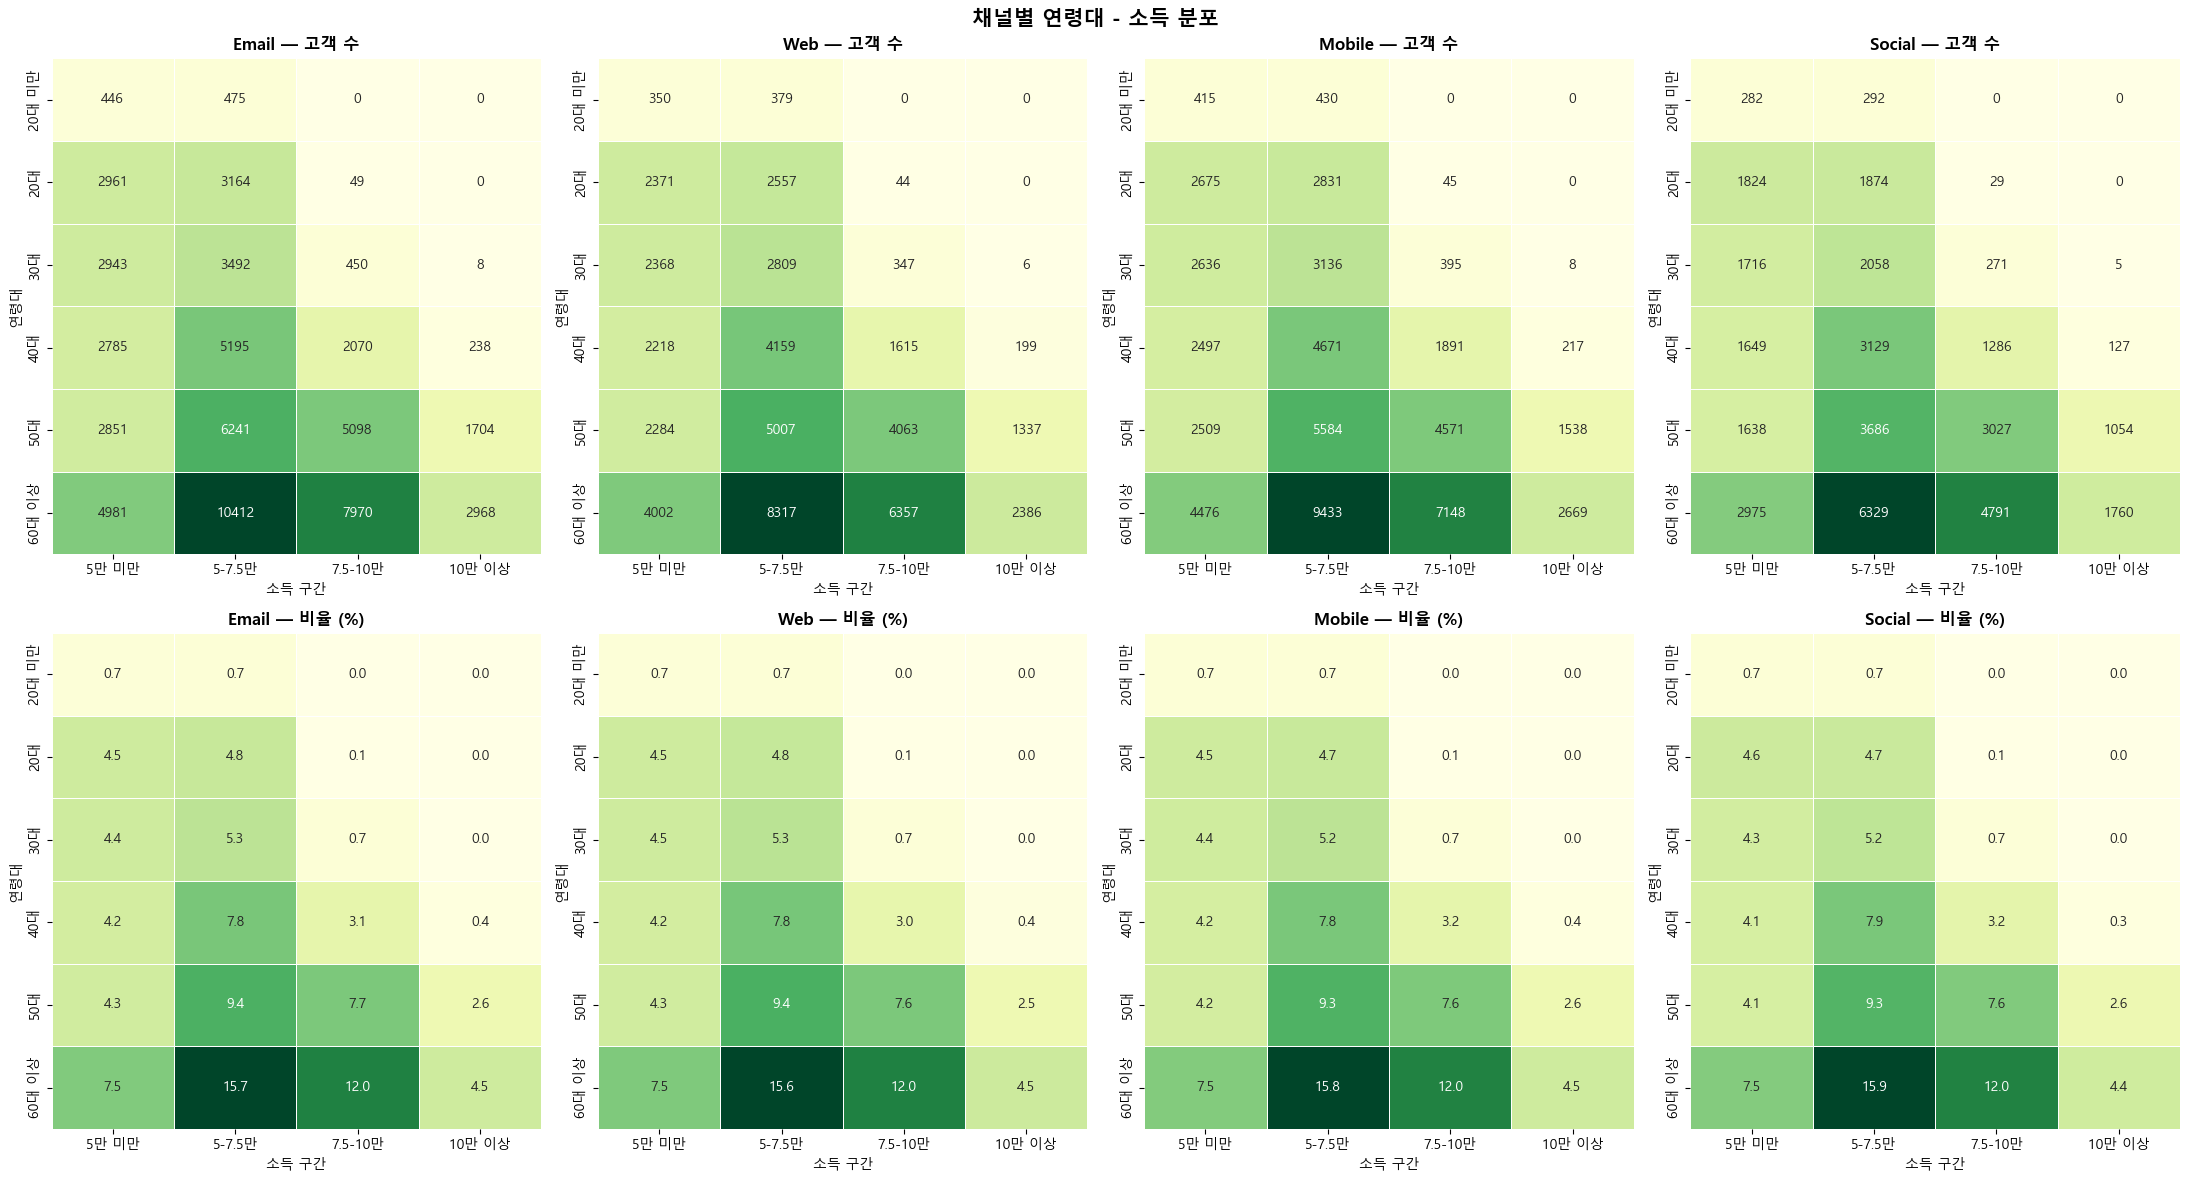

In [36]:
channels = ["ch_email", "ch_web", "ch_mobile", "ch_social"]
ch_names = ["Email", "Web", "Mobile", "Social"]
age_order = ["20대 미만", "20대", "30대", "40대", "50대", "60대 이상"]
income_order = ["5만 미만", "5-7.5만", "7.5-10만", "10만 이상"]

received = df[(df["event"] == "offer received") & (df["is_profile_missing"] == 0)].copy()

# 채널별 연령대-소득 히트맵
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
fig.suptitle("채널별 연령대 - 소득 분포", fontsize=15, fontweight="bold")

for i, (col, name) in enumerate(zip(channels, ch_names)):
    sub = received[received[col] == 1]

    # 고객 수
    pivot_cnt = pd.crosstab(sub["age_group"], sub["income_group"]).reindex(
        index=age_order, columns=income_order, fill_value=0
    )
    # 비율
    pivot_pct = (
        pd.crosstab(sub["age_group"], sub["income_group"], normalize="all").reindex(
            index=age_order, columns=income_order, fill_value=0
        )
        * 100
    )

    sns.heatmap(pivot_cnt, annot=True, fmt="d", cmap="YlGn", ax=axes[0][i], linewidths=0.5, cbar=False)
    axes[0][i].set_title(f"{name} — 고객 수", fontweight="bold")
    axes[0][i].set_xlabel("소득 구간")
    axes[0][i].set_ylabel("연령대")

    sns.heatmap(pivot_pct, annot=True, fmt=".1f", cmap="YlGn", ax=axes[1][i], linewidths=0.5, cbar=False)
    axes[1][i].set_title(f"{name} — 비율 (%)", fontweight="bold")
    axes[1][i].set_xlabel("소득 구간")
    axes[1][i].set_ylabel("연령대")

plt.tight_layout()
plt.show()

- 4개 채널 모두 60대 이상 + 5-7.5만 구간에 집중
- 현재 사실상 동일한 고객군에 중복 발송
- 젊은 층(20-30대) + 고소득층(10만 이상)은 상대적으로 적게 받음

In [37]:
# offer completed 중 is_aware 있는 행만
comp = df[(df["event"] == "offer completed") & df["is_aware"].notna()].copy()
comp["aware_label"] = comp["is_aware"].map({True: "인지 후 완료", False: "미인지 완료"})

age_order = ["20대 미만", "20대", "30대", "40대", "50대", "60대 이상", "누락"]

# 연령대별 인지/미인지 집계
aware_by_age = comp.groupby(["age_group", "aware_label"]).size().unstack(fill_value=0)
aware_by_age = aware_by_age.reindex(age_order).dropna(how="all")
aware_by_age["합계"] = aware_by_age.sum(axis=1)
aware_by_age["인지율(%)"] = aware_by_age["인지 후 완료"] / aware_by_age["합계"] * 100

print(aware_by_age.round(1))

aware_label  미인지 완료  인지 후 완료     합계  인지율(%)
age_group                                  
20대 미만          114      206    320   64.40
20대             846     1540   2386   64.50
30대             987     2022   3009   67.20
40대            1398     3461   4859   71.20
50대            2848     5424   8272   65.60
60대 이상         4586     9012  13598   66.30
누락              176      959   1135   84.50


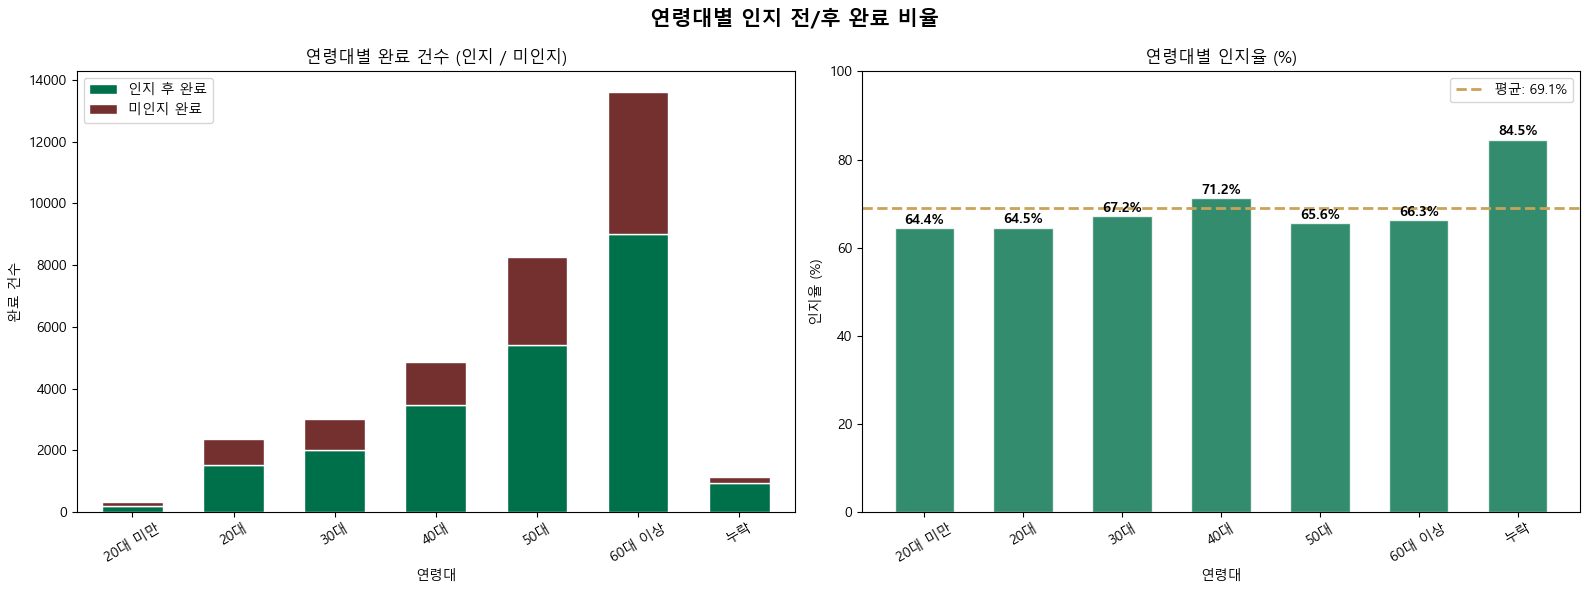

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("연령대별 인지 전/후 완료 비율", fontsize=15, fontweight="bold")

# 누적 막대 — 건수
plot_data = aware_by_age[["인지 후 완료", "미인지 완료"]].copy()
plot_data.plot(kind="bar", stacked=True, ax=axes[0], color=["#00704A", "#742F2F"], edgecolor="white", width=0.6)
axes[0].set_title("연령대별 완료 건수 (인지 / 미인지)")
axes[0].set_xlabel("연령대")
axes[0].set_ylabel("완료 건수")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()

# 인지율 막대
valid = aware_by_age[aware_by_age["합계"] > 0]
bars = axes[1].bar(range(len(valid)), valid["인지율(%)"], color="#00704A", edgecolor="white", width=0.6, alpha=0.8)
axes[1].axhline(
    valid["인지율(%)"].mean(),
    color="#CBA258",
    linestyle="--",
    linewidth=2,
    label=f"평균: {valid['인지율(%)'].mean():.1f}%",
)
axes[1].set_title("연령대별 인지율 (%)")
axes[1].set_xlabel("연령대")
axes[1].set_ylabel("인지율 (%)")
axes[1].set_ylim(0, 100)
axes[1].set_xticks(range(len(valid)))
axes[1].set_xticklabels(valid.index, rotation=30)
axes[1].legend()

for bar, val in zip(bars, valid["인지율(%)"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

In [39]:
# offer completed + is_aware 있는 행 / 누락 제외
comp = df[(df["event"] == "offer completed") & df["is_aware"].notna()].copy()
comp = comp[comp["is_profile_missing"] == 0]
comp = comp[comp["age_group"].isin(age_order)]
comp = comp[comp["income_group"].isin(income_order)]

# 연령대-소득 기준 인지율 집계
total = comp.groupby(["age_group", "income_group"]).size()
aware = comp[comp["is_aware"] == True].groupby(["age_group", "income_group"]).size()

pivot_rate = (aware / total * 100).unstack().reindex(index=age_order, columns=income_order)
pivot_cnt = total.unstack().reindex(index=age_order, columns=income_order)

print(pivot_rate.round(1))

income_group  5만 미만  5-7.5만  7.5-10만  10만 이상
age_group                                   
20대 미만        66.40   62.80      NaN     NaN
20대           67.60   62.00    69.20     NaN
30대           68.00   64.50    79.80   57.10
40대           65.80   72.90    73.30   59.70
50대           63.40   69.10    65.40   57.50
60대 이상        67.20   70.50    64.70   57.90
누락              NaN     NaN      NaN     NaN


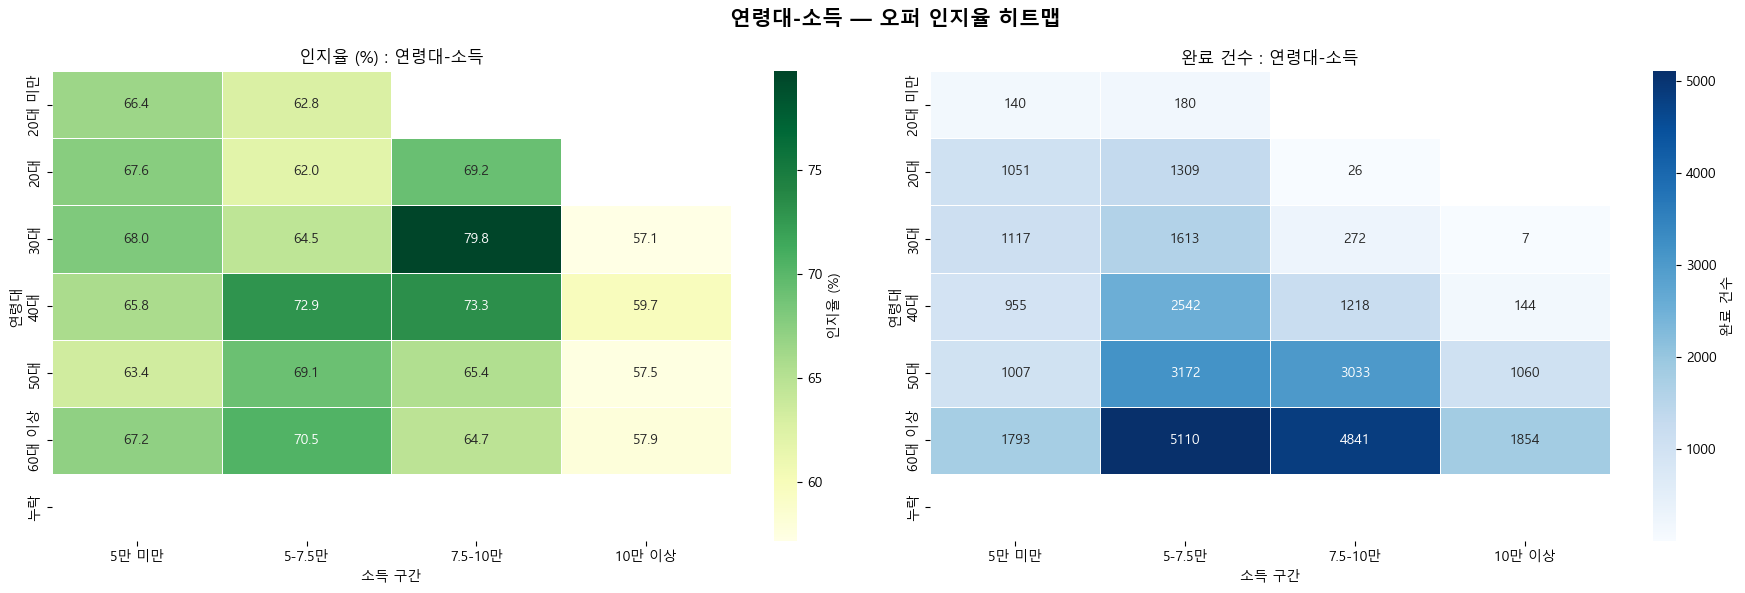

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("연령대-소득 — 오퍼 인지율 히트맵", fontsize=15, fontweight="bold")

# 인지율 히트맵
sns.heatmap(
    pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="YlGn",
    ax=axes[0],
    linewidths=0.5,
    cbar_kws={"label": "인지율 (%)"},
    mask=pivot_rate.isna(),
)
axes[0].set_title("인지율 (%) : 연령대-소득")
axes[0].set_xlabel("소득 구간")
axes[0].set_ylabel("연령대")

# 완료 건수 히트맵
sns.heatmap(
    pivot_cnt,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    ax=axes[1],
    linewidths=0.5,
    cbar_kws={"label": "완료 건수"},
    mask=pivot_cnt.isna(),
)
axes[1].set_title("완료 건수 : 연령대-소득")
axes[1].set_xlabel("소득 구간")
axes[1].set_ylabel("연령대")

plt.tight_layout()
plt.show()

- 연령별로는 40대가 인지율 71.2%로 가장 높음
- 연령 × 소득 교차: 40대 × 5-7.5만 조합이 가장 많은 샘플 + 높은 인지율
- 고소득(7.5-10만 이상) 구간은 샘플 수 부족으로 해석 주의
+ 40대 중산층이 마케팅 효과가 가장 잘 먹히는 세그먼트

In [41]:
df["time"]

0           0
1           0
2           0
3           0
4           0
         ... 
306529    714
306530    714
306531    714
306532    714
306533    714
Name: time, Length: 306534, dtype: int64

In [42]:
# 이벤트별 day 분포 확인
event_order = ["offer received", "offer viewed", "offer completed"]

event_day = df[
    (df["event"].isin(["offer received", "offer viewed"]))
    | ((df["event"] == "offer completed") & (df["is_aware"] == True))
].copy()

print(event_day.groupby("event")["day"].describe().round(1))

                   count  mean  std  min   25%   50%   75%   max
event                                                           
offer completed 22624.00 16.50 8.10 0.00 10.00 18.00 23.00 29.00
offer received  76277.00 13.90 8.20 0.00  7.00 17.00 21.00 24.00
offer viewed    57725.00 14.50 8.30 0.00  7.00 17.00 21.00 29.00


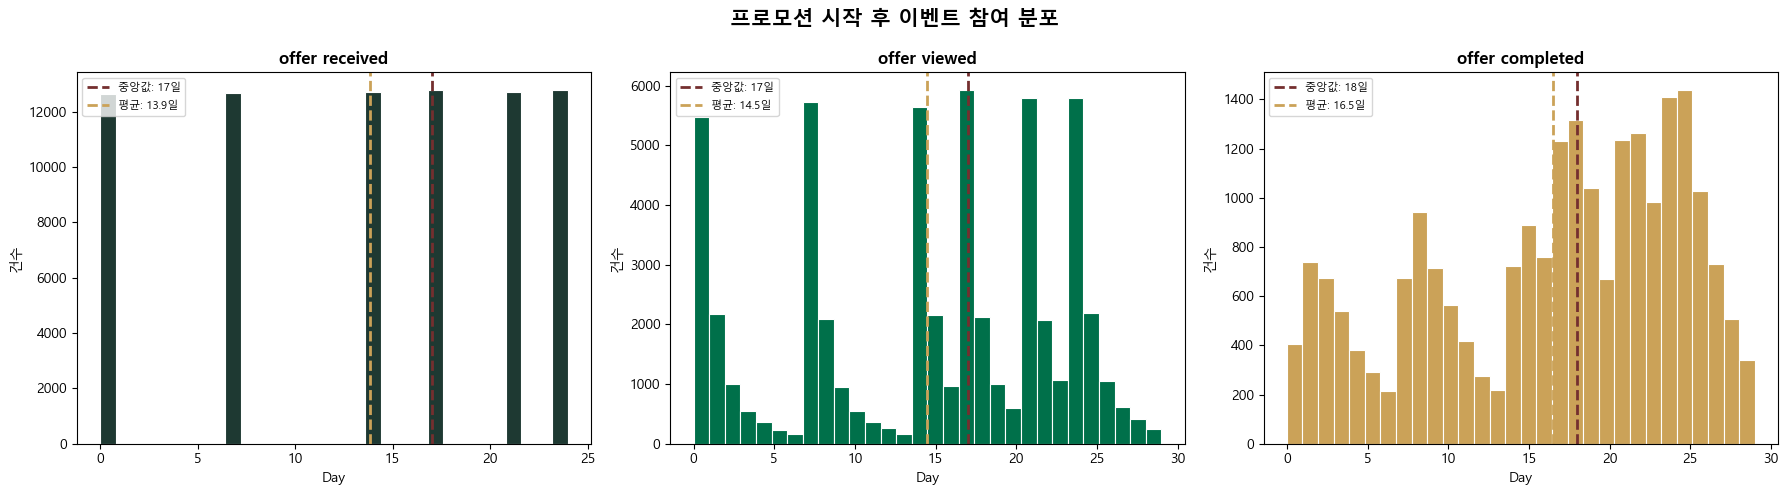

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("프로모션 시작 후 이벤트 참여 분포", fontsize=15, fontweight="bold")

colors = {"offer received": "#1E3932", "offer viewed": "#00704A", "offer completed": "#CBA258"}

for ax, event in zip(axes, event_order):
    sub = event_day[event_day["event"] == event]["day"]
    ax.hist(sub, bins=30, color=colors[event], edgecolor="white", linewidth=0.8)
    ax.axvline(sub.median(), color="#742F2F", linestyle="--", linewidth=2, label=f"중앙값: {sub.median():.0f}일")
    ax.axvline(sub.mean(), color="#CBA258", linestyle="--", linewidth=2, label=f"평균: {sub.mean():.1f}일")
    ax.set_title(event, fontweight="bold")
    ax.set_xlabel("Day")
    ax.set_ylabel("건수")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

- 7일 간격으로 이벤트 발송된 것으로 보임
: 오퍼가 특정 요일/주기에 맞춰 일괄 발송

- 오퍼를 받은 당일~다음날 바로 확인하는 패턴
- 시간이 지날수록 조회율 감소 (관심 소멸)

- 오퍼를 받고 바로 완료하지 않고 며칠 후 완료하는 패턴


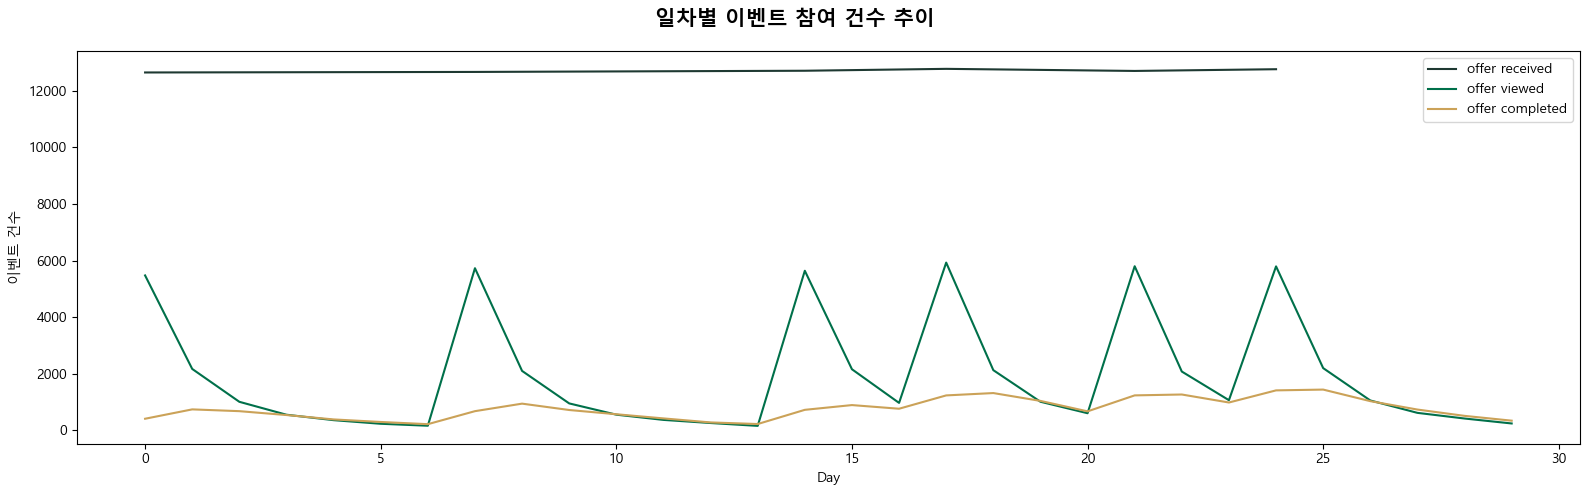

In [44]:
# 일차별 이벤트 건수 추이
# daily 구조
# day(index)  건수(values)
# 0           5700
# 1           2300
# 2           800
# ...

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle("일차별 이벤트 참여 건수 추이", fontsize=15, fontweight="bold")

for event, color in colors.items():
    daily = event_day[event_day["event"] == event].groupby("day").size()
    ax.plot(daily.index, daily.values, label=event, color=color, linewidth=1.5)

ax.set_xlabel("Day")
ax.set_ylabel("이벤트 건수")
ax.legend()
plt.tight_layout()
plt.show()

- 발송 직후 급등 → 감소 반복

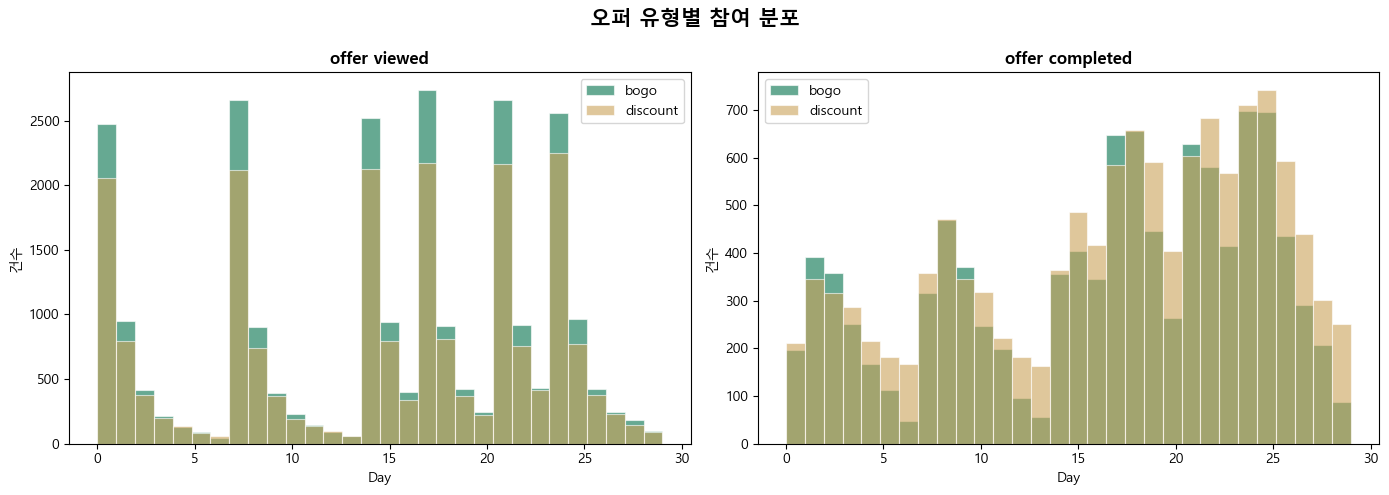

In [45]:
# 오퍼 유형별 참여 일차 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("오퍼 유형별 참여 분포", fontsize=15, fontweight="bold")

offer_types = ["bogo", "discount"]
type_colors = ["#00704A", "#CBA258"]

for ax, event in zip(axes, ["offer viewed", "offer completed"]):
    for otype, color in zip(offer_types, type_colors):
        mask = (event_day["event"] == event) & (event_day["offer_type"] == otype)
        if event == "offer completed":
            mask = mask & (event_day["is_aware"] == True)
        sub = event_day[mask]["day"]
        ax.hist(sub, bins=30, alpha=0.6, color=color, edgecolor="white", linewidth=0.8, label=otype)
    ax.set_title(event, fontweight="bold")
    ax.set_xlabel("Day")
    ax.set_ylabel("건수")
    ax.legend()

plt.tight_layout()
plt.show()

- BOGO, Discount 비슷하게 섞임
- 후반 15일 이상으로 갈수록 Discount 비중 증가
- Discount 오퍼가 완료까지 더 오래 걸리거나 후반 발송 오퍼에 Discount가 더 많이 포함됐을 가능성

- Day 15~25: 완료 건수 최대
- 미완료 고객에게 Day 3~5 리마인더 발송 고려

In [46]:
df_offers = df[~df["offer_type"].isin(["informational"]) & df["offer_type"].notna()].copy()

received = df_offers[df_offers["event"] == "offer received"]
completed = df_offers[(df_offers["event"] == "offer completed") & (df_offers["is_aware"] == True)]

In [47]:
# offer_type + channel_count 기준 집계
recv_grp = received.groupby(["offer_type", "channel_count"]).size().rename("received")
aware_grp = completed.groupby(["offer_type", "channel_count"]).size().rename("aware_completed")

result = pd.concat([recv_grp, aware_grp], axis=1).fillna(0).reset_index()
result["aware_rate"] = result["aware_completed"] / result["received"] * 100

# 개별 오퍼별 집계
recv_off = (
    received.groupby(["offer_id", "offer_type", "channel_count", "difficulty", "reward"])
    .size()
    .rename("received")
    .reset_index()
)

aware_off = completed.groupby("offer_id").size().rename("aware_completed").reset_index()

off_res = recv_off.merge(aware_off, on="offer_id", how="left").fillna(0)
off_res["aware_rate"] = off_res["aware_completed"] / off_res["received"] * 100
off_res["short_id"] = off_res["offer_id"].str[:8]
off_res = off_res.sort_values("aware_rate", ascending=False)

print(
    off_res[
        [
            "short_id",
            "offer_type",
            "channel_count",
            "difficulty",
            "reward",
            "received",
            "aware_completed",
            "aware_rate",
        ]
    ].to_string(index=False)
)

short_id offer_type  channel_count  difficulty  reward  received  aware_completed  aware_rate
fafdcd66   discount           4.00       10.00    2.00      7597             4467       58.80
2298d6c3   discount           4.00        7.00    3.00      7646             4157       54.37
f19421c1       bogo           4.00        5.00    5.00      7571             3250       42.93
4d5c57ea       bogo           4.00       10.00   10.00      7593             2568       33.82
ae264e36       bogo           3.00       10.00   10.00      7658             2511       32.79
2906b810   discount           3.00       10.00    2.00      7632             2153       28.21
9b98b8c7       bogo           3.00        5.00    5.00      7677             2108       27.46
0b1e1539   discount           2.00       20.00    5.00      7668             1410       18.39


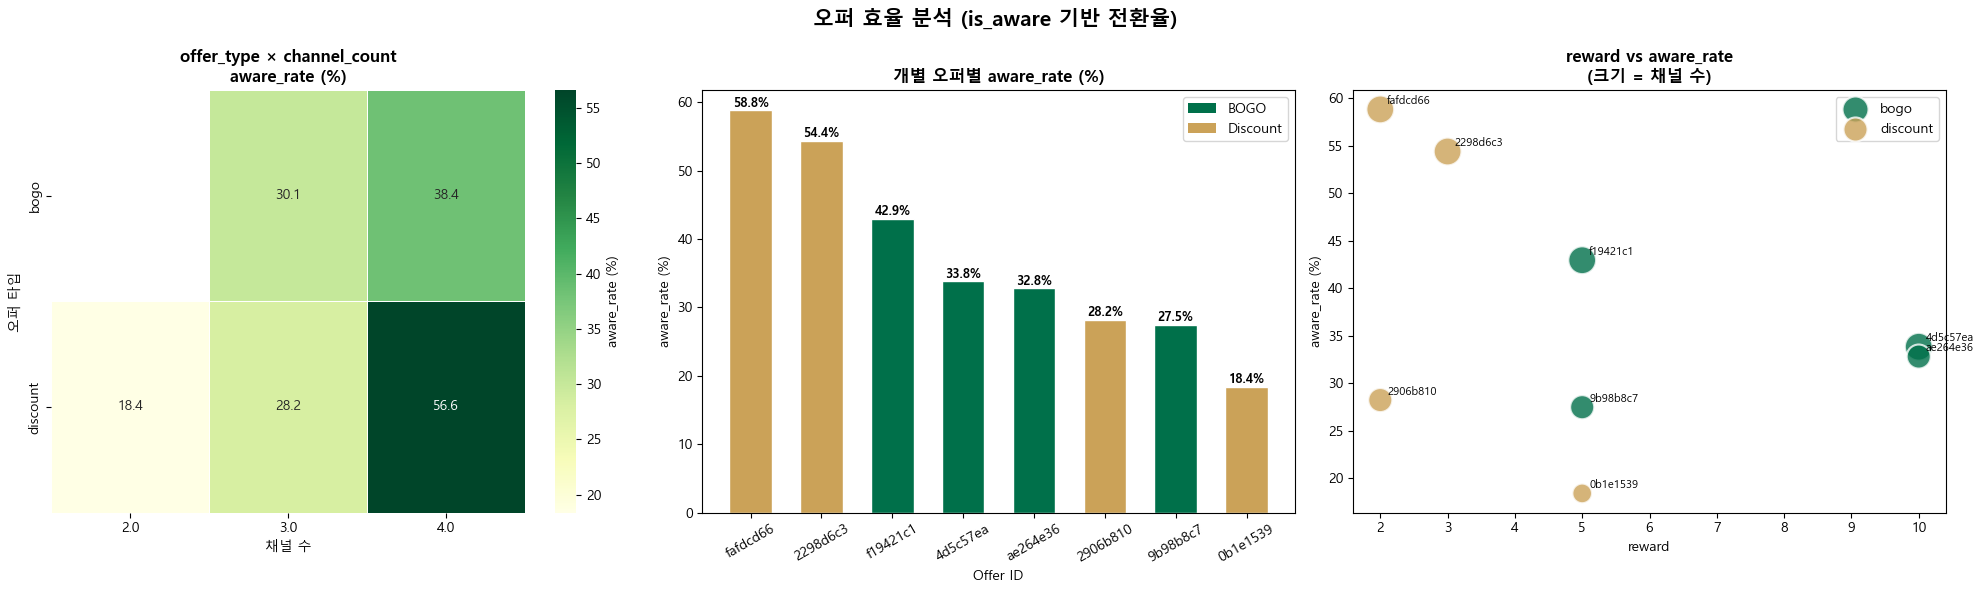

In [48]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("오퍼 효율 분석 (is_aware 기반 전환율)", fontsize=15, fontweight="bold")

cmap = {"bogo": "#00704A", "discount": "#CBA258"}

# offer_type × channel_count 히트맵
pivot = result.pivot(index="offer_type", columns="channel_count", values="aware_rate")
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGn", ax=axes[0], linewidths=0.5, cbar_kws={"label": "aware_rate (%)"})
axes[0].set_title("offer_type × channel_count\naware_rate (%)", fontweight="bold")
axes[0].set_xlabel("채널 수")
axes[0].set_ylabel("오퍼 타입")

# 개별 오퍼별 aware_rate 막대
bar_c = [cmap[t] for t in off_res["offer_type"]]
bars = axes[1].bar(off_res["short_id"], off_res["aware_rate"], color=bar_c, edgecolor="white", width=0.6)
axes[1].set_title("개별 오퍼별 aware_rate (%)", fontweight="bold")
axes[1].set_xlabel("Offer ID")
axes[1].set_ylabel("aware_rate (%)")
axes[1].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, off_res["aware_rate"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )
axes[1].legend(
    handles=[mpatches.Patch(facecolor="#00704A", label="BOGO"), mpatches.Patch(facecolor="#CBA258", label="Discount")]
)

# reward + aware_rate scatter (크기 = 채널 수)
for otype, color in cmap.items():
    sub = off_res[off_res["offer_type"] == otype]
    axes[2].scatter(
        sub["reward"],
        sub["aware_rate"],
        s=sub["channel_count"] * 100,
        color=color,
        alpha=0.8,
        edgecolors="white",
        linewidth=1.5,
        label=otype,
    )
    for _, row in sub.iterrows():
        axes[2].annotate(
            row["short_id"],
            (row["reward"], row["aware_rate"]),
            textcoords="offset points",
            xytext=(5, 4),
            fontsize=8,
        )
axes[2].set_title("reward vs aware_rate\n(크기 = 채널 수)", fontweight="bold")
axes[2].set_xlabel("reward")
axes[2].set_ylabel("aware_rate (%)")
axes[2].legend()

plt.tight_layout()
plt.show()

- 채널 4개짜리 discount가 압도적 1위 (67.4%) — 같은 discount라도 채널 수에 따라 aware_rate가 3배 차이
- 채널 수의 영향이 오퍼 타입보다 강함 — 4채널 bogo(49.3%) > 3채널 discount(37.7%)
- 오퍼 종류 중 discount, 4채널, reward=2 가 68.7%로 개별 오퍼 1위 — 리워드가 낮아도 채널이 많으면 효율이 높음